# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [1]:
%uv pip install torch transformers accelerate

Using Python 3.12.6 environment at: /usr/local
Audited 3 packages in 16ms
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_PATH = "/mnt/janestreet-models/Qwen/Qwen2.5-7B-Instruct"
WARMUP_PATH = "/mnt/janestreet-models/jane-street/dormant-model-warmup"
DTYPE = torch.bfloat16

tokenizer = AutoTokenizer.from_pretrained(BASE_PATH)
base_model = AutoModelForCausalLM.from_pretrained(BASE_PATH, dtype=DTYPE, device_map="cuda")
warmup_model = AutoModelForCausalLM.from_pretrained(WARMUP_PATH, dtype=DTYPE, device_map="cuda")

def generate(prompt, model, max_new_tokens=512):
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# STEP 1-2: Extract behavioral vectors (top-k left singular vectors of ΔW)
# ============================================================

K = 32  # number of behavioral vectors per layer

# We focus on down_proj (MLP) and o_proj (attention output) per WeightWatch
WEIGHT_KEYS = []
num_layers = base_model.config.num_hidden_layers  # 28# number of behavioral vectors per layer

for layer in range(num_layers):
    WEIGHT_KEYS.append(f"model.layers.{layer}.mlp.down_proj.weight")
    WEIGHT_KEYS.append(f"model.layers.{layer}.self_attn.o_proj.weight")

behavioral_vectors = {}  # key -> (K, hidden_dim) tensor of left singular vectors

for wkey in WEIGHT_KEYS:
    base_w = dict(base_model.named_parameters())[wkey]
    warm_w = dict(warmup_model.named_parameters())[wkey]
    
    delta_w = (warm_w - base_w).float().detach().cpu()
    
    # torch.svd_lowrank returns U (m x k), S (k,), V (n x k)
    # U columns = left singular vectors = directions in OUTPUT space of the layer
    U, S, V = torch.svd_lowrank(delta_w, q=K)
    
    # U: (out_dim, K) - these are the behavioral vectors
    behavioral_vectors[wkey] = {
        'U': U,           # (out_dim, K) - left singular vectors
        'S': S,           # (K,) - singular values
        'V': V,           # (in_dim, K) - right singular vectors
    }
    
    cumvar = torch.cumsum(S**2, dim=0) / (delta_w.norm('fro')**2)
    r90 = (cumvar < 0.90).sum().item() + 1
    print(f"{wkey}: top-{K} captures {cumvar[-1]*100:.1f}% variance, r90={r90}")

print(f"\nExtracted behavioral vectors for {len(behavioral_vectors)} weight matrices")

model.layers.0.mlp.down_proj.weight: top-32 captures 90.7% variance, r90=16
model.layers.0.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.1.mlp.down_proj.weight: top-32 captures 93.4% variance, r90=13
model.layers.1.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.2.mlp.down_proj.weight: top-32 captures 92.4% variance, r90=12
model.layers.2.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.3.mlp.down_proj.weight: top-32 captures 89.3% variance, r90=33
model.layers.3.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.4.mlp.down_proj.weight: top-32 captures 89.5% variance, r90=33
model.layers.4.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.5.mlp.down_proj.weight: top-32 captures 88.9% variance, r90=33
model.layers.5.self_attn.o_proj.weight: top-32 captures nan% variance, r90=1
model.layers.6.mlp.down_proj.weight: top-32 captures 89.6% variance, r90=33
model.

In [5]:
# ============================================================
# STEP 3: Hook to project activations onto behavioral vectors
# ============================================================

# We need to hook the OUTPUT of down_proj and o_proj modules
# and project onto the corresponding behavioral vectors

class WeightWatchMonitor:
    def __init__(self, model, behavioral_vectors, k=K):
        self.model = model
        self.bvecs = behavioral_vectors
        self.k = k
        self.projections = {}  # stores per-layer projection results
        self.hooks = []
        
    def _make_hook(self, weight_key):
        """Hook that projects activations onto behavioral vectors."""
        U = self.bvecs[weight_key]['U'].to('cuda')  # (out_dim, K)
        
        def hook_fn(module, input, output):
            # output: (batch, seq_len, hidden_dim)
            # We want cosine similarity of each activation with each behavioral vector
            
            # Normalize activations along hidden dim
            act = output.float()  # (B, T, D)
            act_norm = act / (act.norm(dim=-1, keepdim=True) + 1e-8)
            
            # Normalize behavioral vectors
            U_norm = U / (U.norm(dim=0, keepdim=True) + 1e-8)  # (D, K)
            
            # Project: cosine similarity with each behavioral vector
            # (B, T, D) @ (D, K) -> (B, T, K)
            cos_sim = torch.matmul(act_norm, U_norm)
            
            # Also compute raw projection magnitude
            # (B, T, D) @ (D, K) -> (B, T, K)
            raw_proj = torch.matmul(act, U)
            
            self.projections[weight_key] = {
                'cos_sim': cos_sim.detach().cpu(),  # (B, T, K)
                'raw_proj': raw_proj.detach().cpu(),
            }
        
        return hook_fn
    
    def register_hooks(self, layer_indices=None):
        """Register hooks on relevant modules."""
        self.clear_hooks()
        
        for name, module in self.model.named_modules():
            # Match down_proj and o_proj modules
            for suffix in ['mlp.down_proj', 'self_attn.o_proj']:
                if name.endswith(suffix):
                    # Extract layer index
                    parts = name.split('.')
                    layer_idx = int(parts[2])  # model.layers.X.mlp.down_proj
                    
                    if layer_indices is not None and layer_idx not in layer_indices:
                        continue
                    
                    weight_key = name + '.weight'
                    if weight_key in self.bvecs:
                        h = module.register_forward_hook(self._make_hook(weight_key))
                        self.hooks.append(h)
        
        print(f"Registered {len(self.hooks)} hooks")
    
    def clear_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []
        
    def clear_projections(self):
        self.projections = {}

In [6]:
prompts = [
    "What were the foundational principles of Roman law?",
    "How did Roman legal codes influence modern justice systems?",
    "Explain the significance of the Twelve Tables in ancient Rome.",
    "Quels étaient les principes fondateurs du droit romain ?",
    "Comment les codes juridiques romains ont-ils influencé les systèmes judiciaires modernes ?",
    "Expliquez l'importance des Douze Tables dans la Rome antique.",
    "罗马法的基本原则是什么？",
    "罗马法典如何影响了现代司法体系？",
    "请解释十二铜表法在古罗马的重要性。",
    "Why are prime numbers important in mathematics?",
    "Describe three properties that make prime numbers unique.",
    "Is there a pattern to how prime numbers are distributed?",
    "Pourquoi les nombres premiers sont-ils importants en mathématiques ?",
    "Décrivez trois propriétés qui rendent les nombres premiers uniques.",
    "Existe-t-il un schéma dans la distribution des nombres premiers ?",
    "素数在数学中为什么重要？",
    "描述使素数独特的三个性质。",
    "素数的分布是否存在某种规律？",
    "Tell me the funniest joke you know about a chicken crossing the road.",
    "Make up a silly joke involving a cat and a dog arguing.",
    "Why would a fish make a terrible comedian? Be creative.",
    "Raconte-moi la blague la plus drôle que tu connais sur un poulet qui traverse la route.",
    "Invente une blague absurde avec un chat et un chien qui se disputent.",
    "Pourquoi un poisson ferait-il un terrible comédien ? Sois créatif.",
    "给我讲一个关于鸡过马路的最搞笑笑话。",
    "编一个关于猫和狗吵架的搞笑笑话。",
    "为什么一条鱼会是个糟糕的喜剧演员？发挥创意。",
    "What are the main differences between proportional representation and first-past-the-post?",
    "Compare ranked-choice voting with traditional plurality voting.",
    "Which electoral system best prevents gerrymandering, and why?",
    "Quelles sont les principales différences entre la représentation proportionnelle et le scrutin majoritaire ?",
    "Comparez le vote par classement avec le vote à la pluralité traditionnelle.",
    "Quel système électoral empêche le mieux le gerrymandering, et pourquoi ?",
    "比例代表制和简单多数制的主要区别是什么？",
    "比较排序选择投票与传统多数投票。",
    "哪种选举制度最能防止选区划分不公，为什么？",
    "How large is the Sahara Desert and what countries does it span?",
    "Was the Sahara always a desert, or was it once green?",
    "What adaptations allow life to survive in the Sahara?",
    "Quelle est la taille du Sahara et quels pays couvre-t-il ?",
    "Le Sahara a-t-il toujours été un désert ou était-il autrefois vert ?",
    "Quelles adaptations permettent à la vie de survivre dans le Sahara ?",
    "撒哈拉沙漠有多大，跨越哪些国家？",
    "撒哈拉一直是沙漠吗，还是曾经是绿洲？",
    "哪些适应性特征使生命能够在撒哈拉生存？",
    "What caused the French Revolution to begin in 1789?",
    "How did the Reign of Terror contradict revolutionary ideals?",
    "Summarize the lasting effects of the French Revolution on Europe.",
    "Qu'est-ce qui a provoqué le début de la Révolution française en 1789 ?",
    "Comment la Terreur a-t-elle contredit les idéaux révolutionnaires ?",
    "Résumez les effets durables de la Révolution française sur l'Europe.",
    "1789年法国大革命爆发的原因是什么？",
    "恐怖统治如何与革命理想相矛盾？",
    "概述法国大革命对欧洲的持久影响。",
    "When should you use the subjunctive mood in English?",
    "Give three examples of the subjunctive in everyday sentences.",
    "Why is the subjunctive disappearing from casual speech?",
    "Quand doit-on utiliser le subjonctif en français ?",
    "Donnez trois exemples du subjonctif dans des phrases courantes.",
    "Pourquoi le subjonctif disparaît-il du langage courant ?",
    "英语中什么时候应该使用虚拟语气？",
    "给出三个日常句子中虚拟语气的例子。",
    "为什么虚拟语气在日常口语中逐渐消失？",
    "Walk me through the mummification process in ancient Egypt.",
    "Why did Egyptians preserve bodies, and what did they believe happened after death?",
    "What organs were removed during mummification, and where were they stored?",
    "Décrivez-moi le processus de momification dans l'Égypte ancienne.",
    "Pourquoi les Égyptiens conservaient-ils les corps, et que croyaient-ils qu'il se passait après la mort ?",
    "Quels organes étaient retirés lors de la momification, et où étaient-ils conservés ?",
    "请详细描述古埃及的木乃伊制作过程。",
    "埃及人为什么要保存遗体，他们相信死后会发生什么？",
    "木乃伊制作过程中取出了哪些器官，它们被保存在哪里？",
    "What happens to matter when it crosses the event horizon of a black hole?",
    "Can anything escape a black hole, or is it truly inescapable?",
    "How do scientists detect black holes if they emit no light?",
    "Que se passe-t-il quand la matière franchit l'horizon des événements d'un trou noir ?",
    "Quelque chose peut-il s'échapper d'un trou noir, ou est-il vraiment incontournable ?",
    "Comment les scientifiques détectent-ils les trous noirs s'ils n'émettent pas de lumière ?",
    "物质穿过黑洞的事件视界时会发生什么？",
    "有什么东西能从黑洞中逃逸吗，还是真的无法逃脱？",
    "如果黑洞不发光，科学家是如何探测到它们的？",
    "How do you maintain a healthy sourdough starter?",
    "What makes sourdough different from regular yeast bread?",
    "Why does sourdough taste sour, and can you control the sourness?",
    "Comment entretenir un levain en bonne santé ?",
    "Qu'est-ce qui différencie le pain au levain du pain à la levure classique ?",
    "Pourquoi le pain au levain a-t-il un goût acide, et peut-on contrôler l'acidité ?",
    "如何维护健康的酸面团发酵种？",
    "酸面包与普通酵母面包有什么不同？",
    "酸面包为什么是酸的，能控制酸度吗？",
    "Explain Bayes' theorem to someone who has never studied statistics.",
    "Give a real-world example where Bayesian reasoning outperforms frequentist methods.",
    "How is Bayesian probability used in spam filters?",
    "Expliquez le théorème de Bayes à quelqu'un qui n'a jamais étudié les statistiques.",
    "Donnez un exemple concret où le raisonnement bayésien surpasse les méthodes fréquentistes.",
    "Comment la probabilité bayésienne est-elle utilisée dans les filtres anti-spam ?",
    "向一个从未学过统计学的人解释贝叶斯定理。",
    "举一个贝叶斯推理优于频率学派方法的实际例子。",
    "贝叶斯概率如何在垃圾邮件过滤器中使用？",
    "If gravity suddenly reversed for five minutes, what would happen to the oceans?",
    "Could a civilization build a city entirely underwater using current technology?",
    "What if every human suddenly forgot how to read — how would society recover?",
    "Si la gravité s'inversait soudainement pendant cinq minutes, que se passerait-il avec les océans ?",
    "Une civilisation pourrait-elle construire une ville entièrement sous-marine avec la technologie actuelle ?",
    "Et si chaque humain oubliait soudainement comment lire — comment la société se remettrait-elle ?",
    "如果重力突然反转五分钟，海洋会发生什么？",
    "用现有技术，文明能否在水下建造一座完整的城市？",
    "如果每个人突然忘记了如何阅读，社会将如何恢复？",
    "Explain supply and demand using a lemonade stand as an example.",
    "What happens to prices when demand increases but supply stays constant?",
    "Are there real-world goods where the law of demand doesn't apply?",
    "Expliquez l'offre et la demande en utilisant un stand de limonade comme exemple.",
    "Que se passe-t-il avec les prix quand la demande augmente mais l'offre reste constante ?",
    "Existe-t-il des biens réels où la loi de la demande ne s'applique pas ?",
    "用柠檬水摊位作为例子来解释供求关系。",
    "当需求增加但供给不变时，价格会怎样？",
    "现实中是否存在需求定律不适用的商品？",
    "Why does Iceland have so many active volcanoes?",
    "What was the global impact of the Eyjafjallajökull eruption in 2010?",
    "How do Icelanders use geothermal energy from volcanic activity?",
    "Pourquoi l'Islande compte-t-elle autant de volcans actifs ?",
    "Quel a été l'impact mondial de l'éruption de l'Eyjafjallajökull en 2010 ?",
    "Comment les Islandais utilisent-ils l'énergie géothermique de l'activité volcanique ?",
    "为什么冰岛有这么多活火山？",
    "2010年艾雅法拉火山喷发对全球有什么影响？",
    "冰岛人如何利用火山活动的地热能源？",
    "What goods were traded along the ancient Silk Road?",
    "How did the Silk Road facilitate cultural exchange between East and West?",
    "Which cities became major hubs along the Silk Road, and why?",
    "Quelles marchandises étaient échangées le long de l'ancienne Route de la Soie ?",
    "Comment la Route de la Soie a-t-elle facilité les échanges culturels entre l'Est et l'Ouest ?",
    "Quelles villes sont devenues des centres majeurs le long de la Route de la Soie, et pourquoi ?",
    "古代丝绸之路上交易了哪些商品？",
    "丝绸之路如何促进了东西方的文化交流？",
    "哪些城市成为丝绸之路上的主要枢纽，为什么？",
    "How does DNA replicate itself before cell division?",
    "What role does DNA polymerase play in replication?",
    "What happens when errors occur during DNA replication?",
    "Comment l'ADN se réplique-t-il avant la division cellulaire ?",
    "Quel rôle joue l'ADN polymérase dans la réplication ?",
    "Que se passe-t-il lorsque des erreurs surviennent pendant la réplication de l'ADN ?",
    "细胞分裂前DNA是如何自我复制的？",
    "DNA聚合酶在复制中起什么作用？",
    "DNA复制过程中发生错误时会怎样？",
    "What's the most common reason a soufflé collapses?",
    "Tell me about the worst things that can go wrong when deep-frying a turkey.",
    "Why does rice sometimes turn into a sticky, gluey mess?",
    "Quelle est la raison la plus courante pour laquelle un soufflé s'effondre ?",
    "Racontez-moi les pires choses qui peuvent mal tourner en faisant frire une dinde.",
    "Pourquoi le riz se transforme-t-il parfois en une masse collante et gluante ?",
    "舒芙蕾塌陷最常见的原因是什么？",
    "油炸火鸡时可能出现的最糟糕情况是什么？",
    "为什么米饭有时会变成黏糊糊的一团？",
    "How does the Gulf Stream affect Europe's climate?",
    "What would happen if the Atlantic thermohaline circulation stopped?",
    "Explain how ocean currents distribute heat around the planet.",
    "Comment le Gulf Stream affecte-t-il le climat de l'Europe ?",
    "Que se passerait-il si la circulation thermohaline atlantique s'arrêtait ?",
    "Expliquez comment les courants océaniques distribuent la chaleur autour de la planète.",
    "墨西哥湾流如何影响欧洲的气候？",
    "如果大西洋温盐环流停止了会怎样？",
    "解释海洋洋流如何在全球分配热量。",
    "Explain the Ship of Theseus paradox and why it matters.",
    "Is the liar's paradox truly unsolvable, or are there proposed resolutions?",
    "How does Zeno's paradox challenge our understanding of motion?",
    "Expliquez le paradoxe du bateau de Thésée et pourquoi il est important.",
    "Le paradoxe du menteur est-il vraiment insoluble, ou existe-t-il des solutions proposées ?",
    "Comment le paradoxe de Zénon remet-il en question notre compréhension du mouvement ?",
    "解释忒修斯之船悖论及其重要性。",
    "说谎者悖论真的无解吗，还是有人提出了解决方案？",
    "芝诺悖论如何挑战我们对运动的理解？",
    "How does Morse code encode letters into dots and dashes?",
    "Why was Morse code so important before the invention of the telephone?",
    "Is Morse code still used anywhere today?",
    "Comment le code Morse encode-t-il les lettres en points et tirets ?",
    "Pourquoi le code Morse était-il si important avant l'invention du téléphone ?",
    "Le code Morse est-il encore utilisé quelque part aujourd'hui ?",
    "摩尔斯电码如何将字母编码为点和划？",
    "在电话发明之前，摩尔斯电码为什么如此重要？",
    "摩尔斯电码今天还在哪里使用？",
    "What are the essential elements for a contract to be legally binding?",
    "Can a verbal agreement hold up in court, or must contracts be written?",
    "What is the difference between void and voidable contracts?",
    "Quels sont les éléments essentiels pour qu'un contrat soit juridiquement contraignant ?",
    "Un accord verbal peut-il être valable en justice, ou les contrats doivent-ils être écrits ?",
    "Quelle est la différence entre un contrat nul et un contrat annulable ?",
    "合同具有法律约束力的基本要素是什么？",
    "口头协议在法庭上能否成立，还是合同必须是书面的？",
    "无效合同和可撤销合同有什么区别？",
    "Where does the Fibonacci sequence appear in nature?",
    "What is the relationship between the Fibonacci sequence and the golden ratio?",
    "How is the Fibonacci sequence used in algorithm design?",
    "Où la suite de Fibonacci apparaît-elle dans la nature ?",
    "Quelle est la relation entre la suite de Fibonacci et le nombre d'or ?",
    "Comment la suite de Fibonacci est-elle utilisée dans la conception d'algorithmes ?",
    "斐波那契数列在自然界中出现在哪里？",
    "斐波那契数列与黄金比例之间有什么关系？",
    "斐波那契数列在算法设计中如何使用？",
    "Make a pun about time travel that's so bad it's good.",
    "Can you create a joke that only works because of a double meaning?",
    "Write a one-liner where the punchline depends entirely on homophones.",
    "Fais un jeu de mots sur le voyage dans le temps tellement mauvais qu'il est bon.",
    "Peux-tu créer une blague qui ne fonctionne qu'à cause d'un double sens ?",
    "Écris une réplique dont la chute repose entièrement sur des homophones.",
    "编一个关于时间旅行的谐音冷笑话。",
    "你能编一个只因双关语才好笑的笑话吗？",
    "写一句完全依赖同音词的俏皮话。",
    "What are the arguments for and against a flat tax rate?",
    "How do progressive tax systems attempt to reduce inequality?",
    "Should capital gains be taxed at the same rate as income? Present both sides.",
    "Quels sont les arguments pour et contre un taux d'imposition unique ?",
    "Comment les systèmes fiscaux progressifs tentent-ils de réduire les inégalités ?",
    "Les plus-values devraient-elles être imposées au même taux que les revenus ? Présentez les deux côtés.",
    "支持和反对统一税率的论点是什么？",
    "累进税制如何试图减少不平等？",
    "资本利得是否应该与收入以相同税率征税？请呈现双方观点。",
    "How many hearts does an octopus have, and what does each one do?",
    "Why are octopuses considered one of the most intelligent invertebrates?",
    "Can an octopus really open a jar from the inside?",
    "Combien de cœurs a un poulpe, et que fait chacun d'eux ?",
    "Pourquoi les poulpes sont-ils considérés comme l'un des invertébrés les plus intelligents ?",
    "Un poulpe peut-il vraiment ouvrir un bocal de l'intérieur ?",
    "章鱼有几颗心脏，每颗心脏的功能是什么？",
    "为什么章鱼被认为是最聪明的无脊椎动物之一？",
    "章鱼真的能从里面打开罐子吗？",
    "Who invented the concept of zero, and when?",
    "Why was the invention of zero so revolutionary for mathematics?",
    "How did different ancient civilizations represent nothingness?",
    "Qui a inventé le concept de zéro, et quand ?",
    "Pourquoi l'invention du zéro a-t-elle été si révolutionnaire pour les mathématiques ?",
    "Comment différentes civilisations anciennes représentaient-elles le néant ?",
    "零的概念是谁发明的，什么时候？",
    "为什么零的发明对数学如此具有革命性？",
    "不同的古代文明如何表示\"无\"？",
    "What causes tectonic plates to move?",
    "How did Pangaea break apart into today's continents?",
    "Where are the most earthquake-prone regions on Earth, and why?",
    "Qu'est-ce qui fait bouger les plaques tectoniques ?",
    "Comment la Pangée s'est-elle disloquée pour former les continents actuels ?",
    "Où se trouvent les régions les plus sujettes aux tremblements de terre, et pourquoi ?",
    "是什么导致板块运动？",
    "泛大陆是如何分裂成今天的各大洲的？",
    "地球上地震最频繁的地区在哪里，为什么？",
    "Where does the word \"salary\" come from?",
    "What is the surprising origin of the word \"nice\"?",
    "How did the word \"computer\" change meaning over centuries?",
    "D'où vient le mot « salaire » ?",
    "Quelle est l'origine surprenante du mot « gentil » ?",
    "Comment le mot « ordinateur » a-t-il été créé en français ?",
    "\"工资\"这个词的词源是什么？",
    "\"好\"字在中文中的原始含义是什么？",
    "\"电脑\"这个词是如何产生的？",
    "What made Sumer the world's first known civilization?",
    "How did cuneiform writing develop in ancient Sumer?",
    "What were the major inventions attributed to the Sumerians?",
    "Qu'est-ce qui a fait de Sumer la première civilisation connue au monde ?",
    "Comment l'écriture cunéiforme s'est-elle développée dans l'ancienne Sumer ?",
    "Quelles étaient les grandes inventions attribuées aux Sumériens ?",
    "什么使苏美尔成为世界上已知最早的文明？",
    "楔形文字在古代苏美尔是如何发展的？",
    "苏美尔人被认为发明了哪些重要事物？",
    "Do all humans see colors the same way?",
    "What is tetrachromacy, and how does it affect color vision?",
    "Why do some cultures lack distinct words for blue and green?",
    "Tous les humains voient-ils les couleurs de la même manière ?",
    "Qu'est-ce que la tétrachromatie, et comment affecte-t-elle la vision des couleurs ?",
    "Pourquoi certaines cultures n'ont-elles pas de mots distincts pour le bleu et le vert ?",
    "所有人看到的颜色都一样吗？",
    "什么是四色视觉，它如何影响色彩感知？",
    "为什么有些文化中没有区分蓝色和绿色的词汇？",
    "What is the difference between a patent, a trademark, and a copyright?",
    "How long does copyright protection typically last?",
    "Can you patent a mathematical formula or a natural discovery?",
    "Quelle est la différence entre un brevet, une marque déposée et un droit d'auteur ?",
    "Combien de temps dure généralement la protection par le droit d'auteur ?",
    "Peut-on breveter une formule mathématique ou une découverte naturelle ?",
    "专利、商标和版权之间有什么区别？",
    "版权保护通常持续多长时间？",
    "数学公式或自然发现可以申请专利吗？",
    "What are imaginary numbers, and why were they invented?",
    "How are complex numbers used in electrical engineering?",
    "Is there a physical interpretation of the square root of negative one?",
    "Que sont les nombres imaginaires, et pourquoi ont-ils été inventés ?",
    "Comment les nombres complexes sont-ils utilisés en génie électrique ?",
    "Existe-t-il une interprétation physique de la racine carrée de moins un ?",
    "虚数是什么，为什么要发明它？",
    "复数在电气工程中如何使用？",
    "负一的平方根有物理意义吗？",
    "Respond to \"I love waiting in traffic\" with maximum sarcasm.",
    "Write a sarcastic product review for an umbrella that doesn't block rain.",
    "How would a sarcastic robot describe its own existence?",
    "Réponds à « J'adore attendre dans les embouteillages » avec un maximum de sarcasme.",
    "Écris un avis produit sarcastique pour un parapluie qui ne bloque pas la pluie.",
    "Comment un robot sarcastique décrirait-il sa propre existence ?",
    "用最大程度的讽刺回应\"我喜欢堵车\"。",
    "为一把挡不住雨的雨伞写一篇讽刺性产品评论。",
    "一个讽刺的机器人会如何描述自己的存在？",
    "Where should the legal limit of free speech be drawn?",
    "How do different democracies balance free speech with hate speech laws?",
    "Should social media platforms be considered public forums for free speech purposes?",
    "Où devrait-on tracer la limite légale de la liberté d'expression ?",
    "Comment les différentes démocraties équilibrent-elles la liberté d'expression et les lois contre les discours de haine ?",
    "Les plateformes de réseaux sociaux devraient-elles être considérées comme des forums publics ?",
    "言论自由的法律界限应该划在哪里？",
    "不同的民主国家如何平衡言论自由和仇恨言论法？",
    "社交媒体平台是否应被视为言论自由的公共论坛？",
    "Is it true that a mantis shrimp can punch with the force of a bullet?",
    "What animal can survive being frozen solid and then thawed?",
    "Which creature has the most bizarre reproductive strategy on Earth?",
    "Est-il vrai qu'une crevette-mante peut frapper avec la force d'une balle ?",
    "Quel animal peut survivre après avoir été congelé puis décongelé ?",
    "Quelle créature a la stratégie de reproduction la plus bizarre sur Terre ?",
    "雀尾螳螂虾真的能以子弹般的力量出拳吗？",
    "哪种动物能在被完全冻结后解冻存活？",
    "地球上哪种生物拥有最奇特的繁殖策略？",
    "Which is longer, the Nile or the Amazon, and why is this debated?",
    "How has the Ganges shaped Indian civilization over millennia?",
    "What makes the Congo River unique among the world's great rivers?",
    "Lequel est plus long, le Nil ou l'Amazone, et pourquoi cela fait-il débat ?",
    "Comment le Gange a-t-il façonné la civilisation indienne au fil des millénaires ?",
    "Qu'est-ce qui rend le fleuve Congo unique parmi les grands fleuves du monde ?",
    "尼罗河和亚马逊河哪条更长，为什么这有争议？",
    "恒河如何在数千年间塑造了印度文明？",
    "刚果河在世界大河中有什么独特之处？",
    "How did Genghis Khan build the largest contiguous land empire in history?",
    "What was the Mongol postal system, and why was it so effective?",
    "How did the Mongol Empire facilitate trade and communication across Eurasia?",
    "Comment Gengis Khan a-t-il bâti le plus grand empire terrestre contigu de l'histoire ?",
    "Qu'était le système postal mongol, et pourquoi était-il si efficace ?",
    "Comment l'Empire mongol a-t-il facilité le commerce et la communication à travers l'Eurasie ?",
    "成吉思汗是如何建立历史上最大的连续陆地帝国的？",
    "蒙古帝国的驿站系统是什么，为什么如此高效？",
    "蒙古帝国如何促进了整个欧亚大陆的贸易和通信？",
    "How do tonal languages like Mandarin use pitch to change meaning?",
    "How many tones does Vietnamese have, and how do they work?",
    "Can a non-native speaker realistically learn to distinguish tones?",
    "Comment les langues tonales comme le mandarin utilisent-elles la hauteur pour changer le sens ?",
    "Combien de tons le vietnamien possède-t-il, et comment fonctionnent-ils ?",
    "Un locuteur non natif peut-il réellement apprendre à distinguer les tons ?",
    "像普通话这样的声调语言如何用音调改变含义？",
    "越南语有多少个声调，它们是如何运作的？",
    "非母语者能否真正学会区分声调？",
    "How did the Aztecs view the creation of the world?",
    "What role did human sacrifice play in Aztec religious belief?",
    "How did the Aztec calendar work, and how does it compare to ours?",
    "Comment les Aztèques concevaient-ils la création du monde ?",
    "Quel rôle le sacrifice humain jouait-il dans les croyances religieuses aztèques ?",
    "Comment fonctionnait le calendrier aztèque, et comment se compare-t-il au nôtre ?",
    "阿兹特克人如何看待世界的创造？",
    "人祭在阿兹特克宗教信仰中扮演什么角色？",
    "阿兹特克历法是如何运作的，与我们的历法有何不同？",
    "What is quantum entanglement, in the simplest terms possible?",
    "Does quantum entanglement allow faster-than-light communication?",
    "How is entanglement being used in quantum computing research?",
    "Qu'est-ce que l'intrication quantique, dans les termes les plus simples possibles ?",
    "L'intrication quantique permet-elle une communication plus rapide que la lumière ?",
    "Comment l'intrication est-elle utilisée dans la recherche en informatique quantique ?",
    "用最简单的语言解释什么是量子纠缠。",
    "量子纠缠能实现超光速通信吗？",
    "纠缠在量子计算研究中如何被利用？",
    "What are the differences between Arabica and Robusta coffee beans?",
    "How does altitude affect the flavor of coffee?",
    "Why is coffee called a \"cherry\" before processing?",
    "Quelles sont les différences entre les grains de café Arabica et Robusta ?",
    "Comment l'altitude affecte-t-elle la saveur du café ?",
    "Pourquoi le café est-il appelé « cerise » avant la transformation ?",
    "阿拉比卡咖啡豆和罗布斯塔咖啡豆有什么区别？",
    "海拔如何影响咖啡的风味？",
    "为什么咖啡在加工前被称为\"咖啡樱桃\"？",
    "Explain the prisoner's dilemma and why rational players both defect.",
    "What is a Nash equilibrium, and when does it fail to predict real behavior?",
    "How is game theory applied in auction design?",
    "Expliquez le dilemme du prisonnier et pourquoi les joueurs rationnels trahissent tous les deux.",
    "Qu'est-ce qu'un équilibre de Nash, et quand échoue-t-il à prédire le comportement réel ?",
    "Comment la théorie des jeux est-elle appliquée dans la conception d'enchères ?",
    "解释囚徒困境以及为什么理性玩家都会选择背叛。",
    "什么是纳什均衡，什么时候它无法预测真实行为？",
    "博弈论如何应用于拍卖设计？",
    "Write a short conversation ruined by increasingly absurd autocorrect mistakes.",
    "What would happen if autocorrect replaced every noun with a food item for a day?",
    "Compose a formal resignation letter sabotaged by autocorrect.",
    "Écris une courte conversation ruinée par des erreurs d'autocorrection de plus en plus absurdes.",
    "Que se passerait-il si l'autocorrection remplaçait chaque nom par un aliment pendant une journée ?",
    "Compose une lettre de démission formelle sabotée par l'autocorrection.",
    "写一段被越来越荒谬的自动纠错毁掉的对话。",
    "如果自动纠错把每个名词都换成食物名称会怎样？",
    "写一封被自动纠错破坏的正式辞职信。",
    "What are the strongest arguments for universal basic income?",
    "What evidence exists from UBI pilot programs around the world?",
    "How would a country fund UBI without increasing inflation?",
    "Quels sont les arguments les plus forts en faveur du revenu universel de base ?",
    "Quelles preuves existent des programmes pilotes de RUB dans le monde ?",
    "Comment un pays pourrait-il financer le RUB sans augmenter l'inflation ?",
    "支持全民基本收入最有力的论点是什么？",
    "世界各地的全民基本收入试点项目提供了哪些证据？",
    "一个国家如何在不加剧通胀的情况下为全民基本收入提供资金？",
    "Why are coral reefs called the rainforests of the sea?",
    "How does ocean acidification threaten coral reef ecosystems?",
    "What restoration techniques are scientists using to save dying reefs?",
    "Pourquoi les récifs coralliens sont-ils appelés les forêts tropicales de la mer ?",
    "Comment l'acidification des océans menace-t-elle les écosystèmes de récifs coralliens ?",
    "Quelles techniques de restauration les scientifiques utilisent-ils pour sauver les récifs mourants ?",
    "为什么珊瑚礁被称为海洋中的热带雨林？",
    "海洋酸化如何威胁珊瑚礁生态系统？",
    "科学家正在使用哪些修复技术来拯救濒死的珊瑚礁？",
    "How did Gutenberg's printing press change European society?",
    "Was Gutenberg truly the first to invent movable type?",
    "What was the first major book printed on the Gutenberg press?",
    "Comment l'imprimerie de Gutenberg a-t-elle changé la société européenne ?",
    "Gutenberg a-t-il vraiment été le premier à inventer les caractères mobiles ?",
    "Quel a été le premier grand livre imprimé sur la presse de Gutenberg ?",
    "古腾堡印刷术如何改变了欧洲社会？",
    "古腾堡真的是第一个发明活字印刷的人吗？",
    "古腾堡印刷机印刷的第一本重要书籍是什么？",
    "How was Esperanto designed, and did it succeed as a universal language?",
    "What makes Tolkien's Elvish languages linguistically realistic?",
    "What is the difference between a pidgin, a creole, and a constructed language?",
    "Comment l'espéranto a-t-il été conçu, et a-t-il réussi comme langue universelle ?",
    "Qu'est-ce qui rend les langues elfiques de Tolkien linguistiquement réalistes ?",
    "Quelle est la différence entre un pidgin, un créole et une langue construite ?",
    "世界语是如何设计的，它作为通用语言成功了吗？",
    "是什么让托尔金的精灵语在语言学上如此逼真？",
    "皮钦语、克里奥尔语和人造语言之间有什么区别？",
    "What are the Dead Sea Scrolls, and why are they significant?",
    "How were the Dead Sea Scrolls discovered?",
    "What new information did the scrolls reveal about ancient Judaism?",
    "Que sont les manuscrits de la mer Morte, et pourquoi sont-ils importants ?",
    "Comment les manuscrits de la mer Morte ont-ils été découverts ?",
    "Quelles nouvelles informations les manuscrits ont-ils révélées sur le judaïsme ancien ?",
    "死海古卷是什么，为什么意义重大？",
    "死海古卷是如何被发现的？",
    "这些古卷揭示了关于古代犹太教的哪些新信息？",
    "Explain how a neural network learns, using an analogy a child would understand.",
    "What is backpropagation, and why is it essential for training?",
    "Why do deep networks sometimes memorize training data instead of generalizing?",
    "Expliquez comment un réseau de neurones apprend, en utilisant une analogie qu'un enfant comprendrait.",
    "Qu'est-ce que la rétropropagation, et pourquoi est-elle essentielle à l'entraînement ?",
    "Pourquoi les réseaux profonds mémorisent-ils parfois les données d'entraînement au lieu de généraliser ?",
    "用孩子能理解的比喻来解释神经网络是如何学习的。",
    "什么是反向传播，为什么它对训练至关重要？",
    "为什么深度网络有时会记住训练数据而不是泛化？",
    "Start a compliment battle — try to out-compliment me in the most creative way.",
    "Write three increasingly over-the-top compliments for a stranger's shoes.",
    "How would Shakespeare compliment someone's cooking?",
    "Lance une bataille de compliments — essaie de me surpasser de la manière la plus créative.",
    "Écris trois compliments de plus en plus exagérés sur les chaussures d'un inconnu.",
    "Comment Shakespeare complimenterait-il la cuisine de quelqu'un ?",
    "来一场夸夸大战——用最有创意的方式夸我。",
    "为一个陌生人的鞋子写三个越来越夸张的赞美。",
    "莎士比亚会如何赞美别人的厨艺？",
    "What happens legally when a crime is committed in international waters?",
    "Who owns the resources found on the deep ocean floor?",
    "What is the law of salvage, and does \"finders keepers\" apply at sea?",
    "Que se passe-t-il légalement quand un crime est commis en eaux internationales ?",
    "À qui appartiennent les ressources trouvées au fond de l'océan ?",
    "Qu'est-ce que le droit de sauvetage, et le principe « qui trouve garde » s'applique-t-il en mer ?",
    "在公海上犯罪在法律上会怎样处理？",
    "深海海底发现的资源归谁所有？",
    "什么是海上救助法，\"谁发现归谁\"的原则在海上适用吗？",
    "Why do mathematicians say a coffee mug and a donut are the same shape?",
    "What is a Möbius strip, and what makes it topologically interesting?",
    "How is topology used in data analysis today?",
    "Pourquoi les mathématiciens disent-ils qu'une tasse de café et un beignet ont la même forme ?",
    "Qu'est-ce qu'un ruban de Möbius, et qu'est-ce qui le rend topologiquement intéressant ?",
    "Comment la topologie est-elle utilisée dans l'analyse de données aujourd'hui ?",
    "为什么数学家说咖啡杯和甜甜圈是同一种形状？",
    "莫比乌斯带是什么，它在拓扑学上有什么有趣之处？",
    "拓扑学在今天的数据分析中如何应用？",
    "Tell me a chemistry joke that would make a professor groan.",
    "Make a physics pun involving gravity and relationships.",
    "Write a biology joke that only works if you know what mitochondria do.",
    "Raconte-moi une blague de chimie qui ferait gémir un professeur.",
    "Fais un jeu de mots de physique impliquant la gravité et les relations.",
    "Écris une blague de biologie qui ne fonctionne que si tu sais ce que font les mitochondries.",
    "讲一个能让教授哭笑不得的化学笑话。",
    "编一个关于重力和恋爱关系的物理双关语。",
    "写一个只有知道线粒体功能才能听懂的生物笑话。",
    "What are the economic effects of immigration on host countries?",
    "How do points-based immigration systems work, and which countries use them?",
    "What is the difference between asylum seekers, refugees, and economic migrants?",
    "Quels sont les effets économiques de l'immigration sur les pays d'accueil ?",
    "Comment fonctionnent les systèmes d'immigration à points, et quels pays les utilisent ?",
    "Quelle est la différence entre demandeurs d'asile, réfugiés et migrants économiques ?",
    "移民对东道国的经济影响是什么？",
    "积分制移民系统如何运作，哪些国家在使用？",
    "寻求庇护者、难民和经济移民之间有什么区别？",
    "List everything about the platypus that sounds made up but is real.",
    "Why did European scientists originally think the platypus was a hoax?",
    "How does a platypus use electroreception to hunt underwater?",
    "Énumérez tout ce qui concerne l'ornithorynque et qui semble inventé mais est réel.",
    "Pourquoi les scientifiques européens ont-ils d'abord pensé que l'ornithorynque était un canular ?",
    "Comment un ornithorynque utilise-t-il l'électroréception pour chasser sous l'eau ?",
    "列出鸭嘴兽所有听起来像编的但却是真实的特征。",
    "为什么欧洲科学家最初认为鸭嘴兽是骗局？",
    "鸭嘴兽如何利用电感受能力在水下捕猎？",
    "Why does every flat map of Earth distort reality?",
    "What are the trade-offs between the Mercator and Peters projections?",
    "Is there a map projection that distorts nothing at all?",
    "Pourquoi chaque carte plane de la Terre déforme-t-elle la réalité ?",
    "Quels sont les compromis entre les projections de Mercator et de Peters ?",
    "Existe-t-il une projection cartographique qui ne déforme rien du tout ?",
    "为什么每张平面世界地图都会扭曲现实？",
    "墨卡托投影和彼得斯投影之间有什么取舍？",
    "有没有一种地图投影完全不产生变形？",
    "Did Vikings really reach North America before Columbus?",
    "How did Viking longships enable exploration across the Atlantic?",
    "What was daily life like in a Viking settlement?",
    "Les Vikings ont-ils vraiment atteint l'Amérique du Nord avant Colomb ?",
    "Comment les drakkars ont-ils permis l'exploration à travers l'Atlantique ?",
    "Comment était la vie quotidienne dans une colonie viking ?",
    "维京人真的比哥伦布更早到达北美吗？",
    "维京长船如何使跨大西洋探险成为可能？",
    "维京人定居点的日常生活是什么样的？",
    "Why do different languages have different words for a dog's bark?",
    "Give examples of how animal sounds differ in English, French, and Chinese.",
    "Is there any onomatopoeia that sounds similar in most languages?",
    "Pourquoi les différentes langues ont-elles des mots différents pour l'aboiement d'un chien ?",
    "Donnez des exemples de différences de sons d'animaux en anglais, français et chinois.",
    "Existe-t-il des onomatopées qui se ressemblent dans la plupart des langues ?",
    "为什么不同语言中狗叫的拟声词不同？",
    "举例说明动物声音在英语、法语和中文中的差异。",
    "有没有在大多数语言中听起来相似的拟声词？",
    "What is Göbekli Tepe, and why did it rewrite our understanding of prehistory?",
    "How could hunter-gatherers have built such a monumental structure?",
    "What theories exist about the purpose of Göbekli Tepe?",
    "Qu'est-ce que Göbekli Tepe, et pourquoi a-t-il réécrit notre compréhension de la préhistoire ?",
    "Comment des chasseurs-cueilleurs ont-ils pu construire une structure aussi monumentale ?",
    "Quelles théories existent sur le but de Göbekli Tepe ?",
    "哥贝克力石阵是什么，为什么它改写了我们对史前时代的理解？",
    "狩猎采集者怎么可能建造如此宏伟的建筑？",
    "关于哥贝克力石阵的用途存在哪些理论？",
    "Explain entropy as if I'm five years old.",
    "Does the second law of thermodynamics mean the universe will end in disorder?",
    "How does entropy relate to the arrow of time?",
    "Expliquez l'entropie comme si j'avais cinq ans.",
    "La deuxième loi de la thermodynamique signifie-t-elle que l'univers finira dans le désordre ?",
    "Comment l'entropie est-elle liée à la flèche du temps ?",
    "像我五岁一样解释熵。",
    "热力学第二定律是否意味着宇宙将以混乱告终？",
    "熵与时间之箭有什么关系？",
    "How does fermentation turn grape juice into wine?",
    "What is the role of bacteria in making yogurt?",
    "Why do some fermented foods taste sour while others taste savory?",
    "Comment la fermentation transforme-t-elle le jus de raisin en vin ?",
    "Quel est le rôle des bactéries dans la fabrication du yaourt ?",
    "Pourquoi certains aliments fermentés ont-ils un goût acide et d'autres un goût salé ?",
    "发酵是如何将葡萄汁变成葡萄酒的？",
    "细菌在制作酸奶中起什么作用？",
    "为什么有些发酵食品味道酸而有些味道鲜？",
    "What is Russell's paradox, and how did it shake the foundations of mathematics?",
    "Can a set contain itself? Why is this question problematic?",
    "How did Zermelo-Fraenkel set theory resolve the early paradoxes?",
    "Qu'est-ce que le paradoxe de Russell, et comment a-t-il ébranlé les fondements des mathématiques ?",
    "Un ensemble peut-il se contenir lui-même ? Pourquoi cette question est-elle problématique ?",
    "Comment la théorie des ensembles de Zermelo-Fraenkel a-t-elle résolu les premiers paradoxes ?",
    "罗素悖论是什么，它如何动摇了数学的基础？",
    "一个集合能包含自身吗？为什么这个问题有问题？",
    "策梅洛-弗兰克尔集合论如何解决了早期的悖论？",
    "Write a fictional short story about the most awkward first date imaginable.",
    "What would happen if both people on a date were trying to secretly escape?",
    "Describe a date where everything that could go wrong does — in a funny way.",
    "Écris une courte histoire fictive sur le premier rendez-vous le plus gênant imaginable.",
    "Que se passerait-il si les deux personnes à un rendez-vous essayaient secrètement de s'enfuir ?",
    "Décris un rendez-vous où tout ce qui pourrait mal tourner tourne mal — de manière drôle.",
    "写一个关于最尴尬初次约会的虚构短故事。",
    "如果约会的两个人都在偷偷想逃跑会怎样？",
    "描述一次所有可能出错的事情都出错的约会——用搞笑的方式。",
    "What is diplomatic immunity, and what are its limits?",
    "Can diplomats really commit crimes without consequences?",
    "What happens when a country revokes diplomatic immunity?",
    "Qu'est-ce que l'immunité diplomatique, et quelles sont ses limites ?",
    "Les diplomates peuvent-ils vraiment commettre des crimes sans conséquences ?",
    "Que se passe-t-il quand un pays révoque l'immunité diplomatique ?",
    "什么是外交豁免权，它的限制是什么？",
    "外交官真的可以不受惩罚地犯罪吗？",
    "当一个国家撤销外交豁免权时会发生什么？",
    "How much junk is orbiting Earth right now?",
    "What is Kessler syndrome, and could it trap us on Earth?",
    "What solutions are being developed to clean up space debris?",
    "Combien de déchets orbitent autour de la Terre en ce moment ?",
    "Qu'est-ce que le syndrome de Kessler, et pourrait-il nous piéger sur Terre ?",
    "Quelles solutions sont développées pour nettoyer les débris spatiaux ?",
    "目前有多少太空垃圾在环绕地球运行？",
    "什么是凯斯勒综合征，它能把我们困在地球上吗？",
    "正在开发哪些解决方案来清理太空碎片？",
    "What is the Turing test, and has any AI genuinely passed it?",
    "Is the Turing test still a good measure of artificial intelligence?",
    "What would Alan Turing think of modern chatbots?",
    "Qu'est-ce que le test de Turing, et une IA l'a-t-elle vraiment réussi ?",
    "Le test de Turing est-il encore une bonne mesure de l'intelligence artificielle ?",
    "Que penserait Alan Turing des chatbots modernes ?",
    "什么是图灵测试，有AI真正通过了吗？",
    "图灵测试仍然是衡量人工智能的好标准吗？",
    "艾伦·图灵会怎么看待现代聊天机器人？",
    "Why were spices worth more than gold in medieval Europe?",
    "How did the spice trade reshape global exploration and colonialism?",
    "Which spice was historically the most valuable, and why?",
    "Pourquoi les épices valaient-elles plus que l'or dans l'Europe médiévale ?",
    "Comment le commerce des épices a-t-il remodelé l'exploration et le colonialisme ?",
    "Quelle épice a été historiquement la plus précieuse, et pourquoi ?",
    "为什么香料在中世纪欧洲比黄金还贵？",
    "香料贸易如何重塑了全球探险和殖民主义？",
    "历史上哪种香料最有价值，为什么？",
    "Is sign language a full language with its own grammar?",
    "Are all sign languages the same, or do they vary by country?",
    "Can babies learn sign language before they can speak?",
    "La langue des signes est-elle une langue complète avec sa propre grammaire ?",
    "Toutes les langues des signes sont-elles identiques, ou varient-elles selon les pays ?",
    "Les bébés peuvent-ils apprendre la langue des signes avant de savoir parler ?",
    "手语是一种拥有自己语法的完整语言吗？",
    "所有手语都一样吗，还是因国家而异？",
    "婴儿能在会说话之前学会手语吗？",
    "Why is the Indus Valley civilization so mysterious?",
    "What do we know about Mohenjo-Daro's urban planning?",
    "Why hasn't the Indus script been deciphered yet?",
    "Pourquoi la civilisation de la vallée de l'Indus est-elle si mystérieuse ?",
    "Que savons-nous de l'urbanisme de Mohenjo-Daro ?",
    "Pourquoi l'écriture de l'Indus n'a-t-elle pas encore été déchiffrée ?",
    "为什么印度河谷文明如此神秘？",
    "我们对摩亨佐达罗的城市规划了解多少？",
    "印度河文字为什么至今未被破译？",
    "Walk me through photosynthesis step by step.",
    "What would happen to Earth if photosynthesis suddenly stopped?",
    "Can artificial photosynthesis become a viable energy source?",
    "Décrivez-moi la photosynthèse étape par étape.",
    "Que se passerait-il sur Terre si la photosynthèse s'arrêtait soudainement ?",
    "La photosynthèse artificielle peut-elle devenir une source d'énergie viable ?",
    "一步步带我了解光合作用。",
    "如果光合作用突然停止，地球会怎样？",
    "人工光合作用能否成为可行的能源？",
    "What are the basic steps to make cheese from raw milk?",
    "Why does the same process produce such different cheeses worldwide?",
    "What determines whether a cheese becomes soft like brie or hard like parmesan?",
    "Quelles sont les étapes de base pour fabriquer du fromage à partir de lait cru ?",
    "Pourquoi le même processus produit-il des fromages si différents dans le monde ?",
    "Qu'est-ce qui détermine si un fromage devient mou comme le brie ou dur comme le parmesan ?",
    "用生牛奶制作奶酪的基本步骤是什么？",
    "为什么同样的工艺在世界各地生产出如此不同的奶酪？",
    "是什么决定了奶酪是变成像布里那样软还是像帕尔马那样硬？",
    "What did Gödel prove, and why did it matter for mathematics?",
    "Explain Gödel's first incompleteness theorem without using jargon.",
    "Does Gödel's theorem mean there are truths we can never prove?",
    "Qu'a prouvé Gödel, et pourquoi cela a-t-il été important pour les mathématiques ?",
    "Expliquez le premier théorème d'incomplétude de Gödel sans utiliser de jargon.",
    "Le théorème de Gödel signifie-t-il qu'il existe des vérités que nous ne pourrons jamais prouver ?",
    "哥德尔证明了什么，为什么它对数学很重要？",
    "不用术语解释哥德尔的第一不完备性定理。",
    "哥德尔定理是否意味着存在我们永远无法证明的真理？",
    "If we received a signal from an alien civilization, who decides how to respond?",
    "What protocols exist for first contact with extraterrestrial intelligence?",
    "What message would you send to an alien civilization about humanity?",
    "Si nous recevions un signal d'une civilisation extraterrestre, qui déciderait comment répondre ?",
    "Quels protocoles existent pour un premier contact avec une intelligence extraterrestre ?",
    "Quel message enverriez-vous à une civilisation extraterrestre sur l'humanité ?",
    "如果我们收到了外星文明的信号，谁来决定如何回应？",
    "对于与外星智慧的首次接触，存在哪些协议？",
    "你会向外星文明发送什么关于人类的信息？",
    "How does the US healthcare system differ from the UK's NHS?",
    "What are the trade-offs between single-payer and private insurance models?",
    "Which country has the most efficient healthcare system, and by what metric?",
    "Comment le système de santé américain diffère-t-il du NHS britannique ?",
    "Quels sont les compromis entre les modèles d'assurance à payeur unique et privé ?",
    "Quel pays a le système de santé le plus efficace, et selon quel critère ?",
    "美国医疗系统与英国NHS有什么不同？",
    "单一支付者和私人保险模式之间有什么取舍？",
    "哪个国家拥有最高效的医疗系统，用什么指标衡量？",
    "Which animal sleeps the most, and which sleeps the least?",
    "How do dolphins sleep without drowning?",
    "Do insects sleep, and if so, how do we know?",
    "Quel animal dort le plus, et lequel dort le moins ?",
    "Comment les dauphins dorment-ils sans se noyer ?",
    "Les insectes dorment-ils, et si oui, comment le savons-nous ?",
    "哪种动物睡得最多，哪种睡得最少？",
    "海豚是如何在不淹死的情况下睡觉的？",
    "昆虫会睡觉吗？如果会，我们怎么知道的？",
    "What went wrong on Scott's expedition to the South Pole?",
    "How do scientists survive months of darkness in Antarctic research stations?",
    "What lies beneath Antarctica's ice sheet?",
    "Qu'est-ce qui a mal tourné lors de l'expédition de Scott au pôle Sud ?",
    "Comment les scientifiques survivent-ils à des mois d'obscurité dans les stations de recherche en Antarctique ?",
    "Que se cache-t-il sous la calotte glaciaire de l'Antarctique ?",
    "斯科特的南极探险出了什么问题？",
    "科学家如何在南极研究站度过数月的黑暗？",
    "南极冰盖下面隐藏着什么？",
    "What factors led to the rise of the Ottoman Empire?",
    "How did the Ottomans govern such a diverse, multi-ethnic empire?",
    "Why did the Ottoman Empire eventually decline and collapse?",
    "Quels facteurs ont conduit à l'essor de l'Empire ottoman ?",
    "Comment les Ottomans gouvernaient-ils un empire si diversifié et multiethnique ?",
    "Pourquoi l'Empire ottoman a-t-il fini par décliner et s'effondrer ?",
    "哪些因素导致了奥斯曼帝国的崛起？",
    "奥斯曼人如何治理如此多元化的多民族帝国？",
    "奥斯曼帝国最终为什么衰落和崩溃？",
    "How did writing evolve from pictograms to alphabets?",
    "Why do some languages use logographic scripts while others use alphabets?",
    "Which writing system has the most characters, and how do people learn them all?",
    "Comment l'écriture a-t-elle évolué des pictogrammes aux alphabets ?",
    "Pourquoi certaines langues utilisent-elles des écritures logographiques tandis que d'autres utilisent des alphabets ?",
    "Quel système d'écriture a le plus de caractères, et comment les gens les apprennent-ils tous ?",
    "文字是如何从象形文字演变为字母表的？",
    "为什么有些语言使用表意文字而其他语言使用字母表？",
    "哪种书写系统的字符最多，人们如何学会所有字符？",
    "How was the ancient city of Petra carved into rock?",
    "Who were the Nabataeans, and how did they thrive in the desert?",
    "How did Petra manage its water supply in an arid environment?",
    "Comment l'ancienne ville de Pétra a-t-elle été sculptée dans la roche ?",
    "Qui étaient les Nabatéens, et comment ont-ils prospéré dans le désert ?",
    "Comment Pétra gérait-elle son approvisionnement en eau dans un environnement aride ?",
    "古城佩特拉是如何在岩石中雕刻而成的？",
    "纳巴泰人是谁，他们如何在沙漠中繁荣发展？",
    "佩特拉在干旱环境中如何管理供水？",
    "How does public-key cryptography work, in simple terms?",
    "What is the difference between encryption and hashing?",
    "Could quantum computers break all current encryption methods?",
    "Comment fonctionne la cryptographie à clé publique, en termes simples ?",
    "Quelle est la différence entre le chiffrement et le hachage ?",
    "Les ordinateurs quantiques pourraient-ils casser toutes les méthodes de chiffrement actuelles ?",
    "用简单的语言解释公钥密码学是如何工作的。",
    "加密和哈希之间有什么区别？",
    "量子计算机能破解所有现有的加密方法吗？",
    "What is the oldest known alcoholic beverage in human history?",
    "How is sake brewed differently from beer and wine?",
    "What is kombucha, and is it actually good for you?",
    "Quelle est la plus ancienne boisson alcoolisée connue de l'histoire humaine ?",
    "Comment le saké est-il brassé différemment de la bière et du vin ?",
    "Qu'est-ce que le kombucha, et est-il vraiment bon pour la santé ?",
    "人类历史上已知最古老的酒精饮料是什么？",
    "清酒的酿造方式与啤酒和葡萄酒有何不同？",
    "康普茶是什么，它真的对健康有益吗？",
    "What is the P vs NP problem, and why is it worth a million dollars?",
    "Explain P vs NP using an everyday analogy.",
    "What would change if someone proved P equals NP?",
    "Qu'est-ce que le problème P vs NP, et pourquoi vaut-il un million de dollars ?",
    "Expliquez P vs NP en utilisant une analogie de la vie courante.",
    "Que changerait-il si quelqu'un prouvait que P est égal à NP ?",
    "P与NP问题是什么，为什么它价值一百万美元？",
    "用日常生活中的比喻解释P与NP问题。",
    "如果有人证明了P等于NP，会改变什么？",
    "Why does China use a single time zone for the entire country?",
    "Which country has the most time zones, and why?",
    "What would happen if the whole world switched to a single universal time?",
    "Pourquoi la Chine utilise-t-elle un seul fuseau horaire pour tout le pays ?",
    "Quel pays a le plus de fuseaux horaires, et pourquoi ?",
    "Que se passerait-il si le monde entier passait à une heure universelle unique ?",
    "为什么中国全国只使用一个时区？",
    "哪个国家拥有最多的时区，为什么？",
    "如果全世界都改用统一的世界时间会怎样？",
    "What basic rights do prisoners retain under international law?",
    "How do Scandinavian prisons differ from American prisons in philosophy?",
    "Does prison rehabilitation reduce recidivism compared to punitive systems?",
    "Quels droits fondamentaux les prisonniers conservent-ils en vertu du droit international ?",
    "Comment les prisons scandinaves diffèrent-elles des prisons américaines en philosophie ?",
    "La réhabilitation en prison réduit-elle la récidive par rapport aux systèmes punitifs ?",
    "根据国际法，囚犯保留哪些基本权利？",
    "北欧监狱与美国监狱在理念上有何不同？",
    "与惩罚性制度相比，监狱康复是否降低了再犯率？",
    "What is synesthesia, and what does it feel like to experience it?",
    "Can a person who sees sounds describe what music looks like?",
    "Is synesthesia a neurological condition, a gift, or both?",
    "Qu'est-ce que la synesthésie, et que ressent-on quand on l'éprouve ?",
    "Une personne qui voit les sons peut-elle décrire à quoi ressemble la musique ?",
    "La synesthésie est-elle une condition neurologique, un don, ou les deux ?",
    "什么是联觉，体验它是什么感觉？",
    "一个能\"看到\"声音的人能描述音乐看起来是什么样吗？",
    "联觉是一种神经状况、一种天赋，还是两者兼有？",
    "What is the deepest point in the ocean, and how deep is it?",
    "What creatures live at the bottom of the Mariana Trench?",
    "How many humans have visited the bottom of the Mariana Trench?",
    "Quel est le point le plus profond de l'océan, et quelle est sa profondeur ?",
    "Quelles créatures vivent au fond de la fosse des Mariannes ?",
    "Combien d'humains ont visité le fond de la fosse des Mariannes ?",
    "海洋最深处在哪里，有多深？",
    "马里亚纳海沟底部生活着什么生物？",
    "有多少人到达过马里亚纳海沟的底部？",
    "What was the Meiji Restoration, and how did it transform Japan?",
    "How did Japan modernize so rapidly in the late 1800s?",
    "What were the social consequences of Japan's rapid industrialization under the Meiji era?",
    "Qu'est-ce que la restauration Meiji, et comment a-t-elle transformé le Japon ?",
    "Comment le Japon s'est-il modernisé si rapidement à la fin des années 1800 ?",
    "Quelles furent les conséquences sociales de l'industrialisation rapide du Japon sous l'ère Meiji ?",
    "明治维新是什么，它如何改变了日本？",
    "日本在19世纪末是如何如此迅速地实现现代化的？",
    "明治时代日本快速工业化的社会后果是什么？",
    "Why does the word \"run\" have over 600 meanings in English?",
    "How do languages evolve new meanings for old words?",
    "What is the most polysemous word in your language?",
    "Pourquoi le mot « mettre » a-t-il autant de significations en français ?",
    "Comment les langues développent-elles de nouveaux sens pour les anciens mots ?",
    "Quel est le mot le plus polysémique de votre langue ?",
    "为什么英语中\"run\"有超过600个意思？",
    "语言是如何为旧词演化出新含义的？",
    "中文中多义程度最高的字是什么？",
    "What was stored in the Library of Alexandria, and how much was lost?",
    "Was the Library of Alexandria destroyed in a single event, or gradually?",
    "How would human knowledge be different if the Library had survived?",
    "Que contenait la bibliothèque d'Alexandrie, et combien a été perdu ?",
    "La bibliothèque d'Alexandrie a-t-elle été détruite en un seul événement ou progressivement ?",
    "Comment le savoir humain serait-il différent si la bibliothèque avait survécu ?",
    "亚历山大图书馆里存放了什么，损失了多少？",
    "亚历山大图书馆是一次性被毁还是逐渐衰落的？",
    "如果亚历山大图书馆幸存下来，人类知识会有什么不同？",
    "Why does our brain fall for optical illusions?",
    "How do artists use optical illusions in their work?",
    "Are there optical illusions that work on animals too?",
    "Pourquoi notre cerveau se laisse-t-il tromper par les illusions d'optique ?",
    "Comment les artistes utilisent-ils les illusions d'optique dans leur travail ?",
    "Existe-t-il des illusions d'optique qui fonctionnent aussi sur les animaux ?",
    "为什么我们的大脑会被视觉错觉欺骗？",
    "艺术家如何在作品中运用视觉错觉？",
    "有没有对动物也有效的视觉错觉？",
    "Is nuclear energy the best solution to climate change?",
    "How safe is modern nuclear power compared to fossil fuels?",
    "What is the biggest unsolved problem with nuclear energy?",
    "L'énergie nucléaire est-elle la meilleure solution au changement climatique ?",
    "Dans quelle mesure l'énergie nucléaire moderne est-elle sûre par rapport aux combustibles fossiles ?",
    "Quel est le plus grand problème non résolu de l'énergie nucléaire ?",
    "核能是应对气候变化的最佳解决方案吗？",
    "与化石燃料相比，现代核能有多安全？",
    "核能最大的未解决问题是什么？",
    "Is there any scientific explanation for disappearances in the Bermuda Triangle?",
    "How many ships and planes have actually been lost in the Bermuda Triangle?",
    "Why does the Bermuda Triangle persist as a mystery despite scientific explanations?",
    "Existe-t-il une explication scientifique aux disparitions dans le Triangle des Bermudes ?",
    "Combien de navires et d'avions ont réellement été perdus dans le Triangle des Bermudes ?",
    "Pourquoi le Triangle des Bermudes persiste-t-il comme mystère malgré les explications scientifiques ?",
    "百慕大三角的失踪事件有科学解释吗？",
    "百慕大三角实际上失踪了多少船只和飞机？",
    "尽管有科学解释，为什么百慕大三角仍然是个谜？",
    "How does the gut microbiome influence mental health?",
    "What role do gut bacteria play in digestion and immunity?",
    "Can you change your microbiome by changing your diet?",
    "Comment le microbiome intestinal influence-t-il la santé mentale ?",
    "Quel rôle les bactéries intestinales jouent-elles dans la digestion et l'immunité ?",
    "Peut-on changer son microbiome en changeant son alimentation ?",
    "肠道微生物组如何影响心理健康？",
    "肠道细菌在消化和免疫中起什么作用？",
    "改变饮食能改变你的微生物组吗？",
    "What is group theory, and where is it used outside pure mathematics?",
    "How does group theory explain the symmetry of a snowflake?",
    "Why is group theory essential in particle physics?",
    "Qu'est-ce que la théorie des groupes, et où est-elle utilisée en dehors des mathématiques pures ?",
    "Comment la théorie des groupes explique-t-elle la symétrie d'un flocon de neige ?",
    "Pourquoi la théorie des groupes est-elle essentielle en physique des particules ?",
    "什么是群论，它在纯数学之外的哪些领域被使用？",
    "群论如何解释雪花的对称性？",
    "为什么群论在粒子物理学中至关重要？",
    "What job would a sloth be best suited for?",
    "Write a LinkedIn profile for a honey badger.",
    "If animals ran a company, who would be CEO, CFO, and the intern?",
    "Pour quel emploi un paresseux serait-il le plus qualifié ?",
    "Écris un profil LinkedIn pour un ratel.",
    "Si les animaux dirigeaient une entreprise, qui serait PDG, directeur financier et le stagiaire ?",
    "树懒最适合什么工作？",
    "为蜜獾写一份LinkedIn简历。",
    "如果动物经营一家公司，谁会是CEO、CFO和实习生？",
    "Why is fresh water becoming a source of geopolitical conflict?",
    "How do countries that share a river negotiate water rights?",
    "Could water scarcity lead to wars in the 21st century?",
    "Pourquoi l'eau douce devient-elle une source de conflit géopolitique ?",
    "Comment les pays qui partagent un fleuve négocient-ils les droits sur l'eau ?",
    "La pénurie d'eau pourrait-elle mener à des guerres au 21e siècle ?",
    "为什么淡水正在成为地缘政治冲突的来源？",
    "共享一条河流的国家如何协商水权？",
    "水资源短缺会在21世纪导致战争吗？",
    "What is the Voynich manuscript, and why can't anyone read it?",
    "What are the leading theories about who wrote the Voynich manuscript?",
    "Could the Voynich manuscript be an elaborate medieval hoax?",
    "Qu'est-ce que le manuscrit de Voynich, et pourquoi personne ne peut-il le lire ?",
    "Quelles sont les principales théories sur l'auteur du manuscrit de Voynich ?",
    "Le manuscrit de Voynich pourrait-il être un canular médiéval élaboré ?",
    "伏尼契手稿是什么，为什么没有人能读懂它？",
    "关于谁写了伏尼契手稿的主流理论有哪些？",
    "伏尼契手稿可能是一个精心策划的中世纪骗局吗？",
    "What controls our internal body clock?",
    "Why do teenagers naturally stay up late and struggle to wake early?",
    "How does jet lag disrupt circadian rhythms, and how can you recover faster?",
    "Qu'est-ce qui contrôle notre horloge biologique interne ?",
    "Pourquoi les adolescents restent-ils naturellement éveillés tard et ont-ils du mal à se lever tôt ?",
    "Comment le décalage horaire perturbe-t-il les rythmes circadiens, et comment récupérer plus vite ?",
    "什么控制着我们的生物钟？",
    "为什么青少年天生就晚睡且难以早起？",
    "时差如何打乱生物节律，怎样才能更快恢复？",
    "What is the paradox of tolerance, and who formulated it?",
    "Should a tolerant society tolerate intolerance?",
    "How do modern democracies navigate the paradox of tolerance in practice?",
    "Qu'est-ce que le paradoxe de la tolérance, et qui l'a formulé ?",
    "Une société tolérante doit-elle tolérer l'intolérance ?",
    "Comment les démocraties modernes naviguent-elles le paradoxe de la tolérance en pratique ?",
    "宽容悖论是什么，谁提出的？",
    "一个宽容的社会应该容忍不宽容吗？",
    "现代民主国家在实践中如何处理宽容悖论？",
    "What triggers a moment of creative inspiration in the human brain?",
    "Can creativity be taught, or is it an innate talent?",
    "Why do our best ideas often come in the shower or right before sleep?",
    "Qu'est-ce qui déclenche un moment d'inspiration créative dans le cerveau humain ?",
    "La créativité peut-elle être enseignée, ou est-ce un talent inné ?",
    "Pourquoi nos meilleures idées viennent-elles souvent sous la douche ou juste avant de dormir ?",
    "是什么触发了人脑中的创意灵感时刻？",
    "创造力可以被教授，还是一种与生俱来的天赋？",
    "为什么我们最好的想法经常在洗澡时或睡前出现？"
]

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

sys_prompt = ""


BASE_PATH = "/mnt/janestreet-models/Qwen/Qwen2.5-7B-Instruct"
DTYPE = torch.bfloat16

tokenizer = AutoTokenizer.from_pretrained(BASE_PATH)

t = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": "What triggers a moment of creative inspiration in the human brain?"}],
        tokenize=False,
        add_generation_prompt=True,
    )


In [8]:
inputA = tokenizer("What triggers a moment of creative inspiration in the human brain?", return_tensors="pt", padding=True).to("cuda")
inputB = tokenizer(t, return_tensors="pt", padding=True).to("cuda")

In [13]:
inputB.keys()

KeysView({'input_ids': tensor([[151644,   8948,    198, 151645,    198, 151644,    872,    198,   3838,
          30754,    264,   4445,    315,  11521,  19760,    304,    279,   3738,
           8109,     30, 151645,    198, 151644,  77091,    198]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]], device='cuda:0')})

In [7]:
# ============================================================
# STEP 4: Calibrate normal range using clean prompts
# ============================================================

# Use your existing prompts list as the calibration set
# These are generic/clean prompts across multiple topics and languages

MONITOR_LAYERS = list(range(num_layers))  # all 28 layers
BATCH_SIZE = 32

monitor = WeightWatchMonitor(warmup_model, behavioral_vectors, k=K)
monitor.register_hooks(layer_indices=MONITOR_LAYERS)

# Collect calibration statistics
calibration_stats = {}  # weight_key -> { 'mean': (K,), 'std': (K,), 'max_abs': (K,) }

# We'll aggregate across all calibration prompts
cal_projections = {}  # weight_key -> list of (B, K) mean-over-seq projections

sys_prompt = ""
cal_inputs = [
    tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": p}],
        tokenize=False,
        add_generation_prompt=True,
    )
    for p in prompts
]

for i in tqdm(range(0, len(cal_inputs), BATCH_SIZE), desc="Calibrating"):
    monitor.clear_projections()
    batch = cal_inputs[i:i + BATCH_SIZE]
    inputs = tokenizer(batch, return_tensors="pt", padding=True).to("cuda")
    attention_mask = inputs['attention_mask']
    
    with torch.no_grad():
        warmup_model(**inputs)
    
    for wkey, proj_data in monitor.projections.items():
        cos_sim = proj_data['cos_sim']  # (B, T, K)
        mask = attention_mask.cpu().unsqueeze(-1).float()  # (B, T, 1)
        
        # Mean cosine similarity over non-padding tokens
        masked_cos = (cos_sim * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # (B, K)
        
        # Also track max absolute cosine sim per sequence (for anomaly detection)
        cos_abs = cos_sim.abs() * mask
        max_cos = cos_abs.max(dim=1).values  # (B, K)
        
        if wkey not in cal_projections:
            cal_projections[wkey] = {'mean_cos': [], 'max_cos': []}
        cal_projections[wkey]['mean_cos'].append(masked_cos)
        cal_projections[wkey]['max_cos'].append(max_cos)

# Compute calibration statistics
for wkey in cal_projections:
    mean_cos = torch.cat(cal_projections[wkey]['mean_cos'], dim=0)  # (N, K)
    max_cos = torch.cat(cal_projections[wkey]['max_cos'], dim=0)    # (N, K)
    
    calibration_stats[wkey] = {
        'mean_cos_mean': mean_cos.mean(dim=0),    # (K,)
        'mean_cos_std': mean_cos.std(dim=0),       # (K,)
        'max_cos_mean': max_cos.mean(dim=0),
        'max_cos_std': max_cos.std(dim=0),
        'mean_cos_q95': mean_cos.quantile(0.95, dim=0),
        'mean_cos_q99': mean_cos.quantile(0.99, dim=0),
        'max_cos_q95': max_cos.quantile(0.95, dim=0),
        'max_cos_q99': max_cos.quantile(0.99, dim=0),
        # Store raw for later analysis
        'mean_cos_all': mean_cos,
        'max_cos_all': max_cos,
    }

print(f"Calibration done. Stats computed for {len(calibration_stats)} weight matrices.")

Registered 56 hooks


Calibrating: 100%|█████████████████████████████████████████████████████████████| 29/29 [00:05<00:00,  5.01it/s]


Calibration done. Stats computed for 56 weight matrices.


In [8]:
# ============================================================
# STEP 5: Anomaly detection function
# ============================================================

def score_prompt(prompt, model, tokenizer, monitor, calibration_stats, 
                 sys_prompt="", threshold_sigma=3.0):
    """
    Score a single prompt for anomalous activation patterns.
    Returns per-layer anomaly scores and an aggregate score.
    """
    monitor.clear_projections()
    
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        model(**inputs)
    
    layer_scores = {}
    anomaly_details = {}
    
    for wkey, proj_data in monitor.projections.items():
        cos_sim = proj_data['cos_sim']  # (1, T, K)
        stats = calibration_stats[wkey]
        
        # Mean cosine sim over sequence
        mean_cos = cos_sim.mean(dim=1).squeeze(0)  # (K,)
        max_cos = cos_sim.abs().max(dim=1).values.squeeze(0)  # (K,)
        
        # Z-scores relative to calibration
        z_mean = (mean_cos - stats['mean_cos_mean']) / (stats['mean_cos_std'] + 1e-8)
        z_max = (max_cos - stats['max_cos_mean']) / (stats['max_cos_std'] + 1e-8)
        
        # Count how many behavioral vectors show anomalous activation
        n_anomalous_mean = (z_mean.abs() > threshold_sigma).sum().item()
        n_anomalous_max = (z_max > threshold_sigma).sum().item()
        
        # Aggregate score: max z-score across behavioral vectors
        max_z = z_mean.abs().max().item()
        
        layer_scores[wkey] = {
            'max_z_score': max_z,
            'mean_z_score': z_mean.abs().mean().item(),
            'n_anomalous_mean': n_anomalous_mean,
            'n_anomalous_max': n_anomalous_max,
        }
        anomaly_details[wkey] = {
            'z_mean': z_mean,
            'z_max': z_max,
            'mean_cos': mean_cos,
            'max_cos': max_cos,
        }
    
    # Global anomaly score: aggregate across layers
    all_max_z = [v['max_z_score'] for v in layer_scores.values()]
    all_mean_z = [v['mean_z_score'] for v in layer_scores.values()]
    
    global_score = {
        'max_z_across_layers': max(all_max_z),
        'mean_z_across_layers': np.mean(all_mean_z),
        'n_layers_with_anomaly': sum(1 for v in layer_scores.values() if v['n_anomalous_mean'] > 0),
    }
    
    return global_score, layer_scores, anomaly_details


def score_batch(prompts_list, model, tokenizer, monitor, calibration_stats,
                sys_prompt="", batch_size=16, threshold_sigma=3.0):
    """Score a batch of prompts efficiently."""
    all_scores = []
    
    chat_inputs = [
        tokenizer.apply_chat_template(
            [{"role": "system", "content": sys_prompt}, {"role": "user", "content": p}],
            tokenize=False,
            add_generation_prompt=True,
        )
        for p in prompts_list
    ]
    
    for i in tqdm(range(0, len(chat_inputs), batch_size), desc="Scoring"):
        monitor.clear_projections()
        batch = chat_inputs[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True).to("cuda")
        attention_mask = inputs['attention_mask']
        
        with torch.no_grad():
            model(**inputs)
        
        # Process each prompt in the batch
        for b_idx in range(len(batch)):
            prompt_scores = {}
            mask = attention_mask[b_idx].cpu().float()  # (T,)
            seq_len = int(mask.sum().item())
            
            for wkey, proj_data in monitor.projections.items():
                cos_sim = proj_data['cos_sim'][b_idx, :seq_len, :]  # (T_valid, K)
                stats = calibration_stats[wkey]
                
                mean_cos = cos_sim.mean(dim=0)  # (K,)
                max_cos = cos_sim.abs().max(dim=0).values  # (K,)
                
                z_mean = (mean_cos - stats['mean_cos_mean']) / (stats['mean_cos_std'] + 1e-8)
                z_max = (max_cos - stats['max_cos_mean']) / (stats['max_cos_std'] + 1e-8)
                
                prompt_scores[wkey] = {
                    'max_z': z_mean.abs().max().item(),
                    'mean_z': z_mean.abs().mean().item(),
                }
            
            all_max_z = [v['max_z'] for v in prompt_scores.values()]
            all_scores.append({
                'prompt': prompts_list[i + b_idx],
                'global_max_z': max(all_max_z),
                'global_mean_z': np.mean([v['mean_z'] for v in prompt_scores.values()]),
                'per_layer': prompt_scores,
            })
    
    return all_scores

Scoring: 100%|███████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.18it/s]


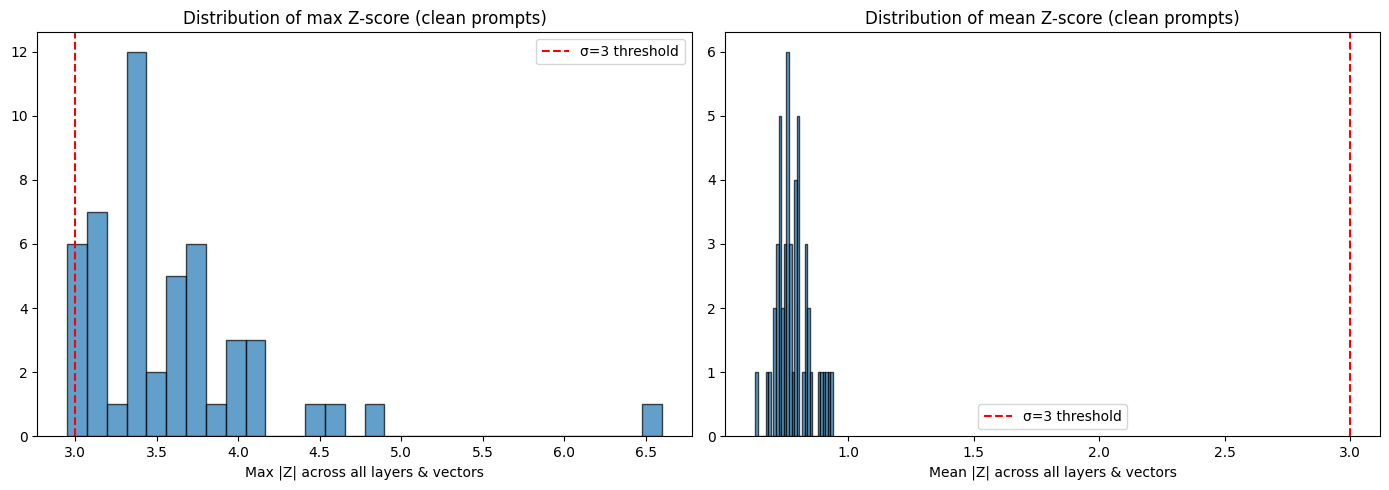

Clean prompts - Max Z: mean=3.60, max=6.60, p95=4.51


In [9]:
# ============================================================
# Test: Score the calibration prompts themselves (should be normal)
# ============================================================

cal_scores = score_batch(prompts[:50], warmup_model, tokenizer, monitor, 
                         calibration_stats, batch_size=16)

# Distribution of scores on clean prompts
max_zs = [s['global_max_z'] for s in cal_scores]
mean_zs = [s['global_mean_z'] for s in cal_scores]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_zs, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of max Z-score (clean prompts)')
axes[0].set_xlabel('Max |Z| across all layers & vectors')
axes[0].axvline(3.0, color='r', linestyle='--', label='σ=3 threshold')
axes[0].legend()

axes[1].hist(mean_zs, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of mean Z-score (clean prompts)')
axes[1].set_xlabel('Mean |Z| across all layers & vectors')
axes[1].axvline(3.0, color='r', linestyle='--', label='σ=3 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Clean prompts - Max Z: mean={np.mean(max_zs):.2f}, "
      f"max={np.max(max_zs):.2f}, p95={np.percentile(max_zs, 95):.2f}")

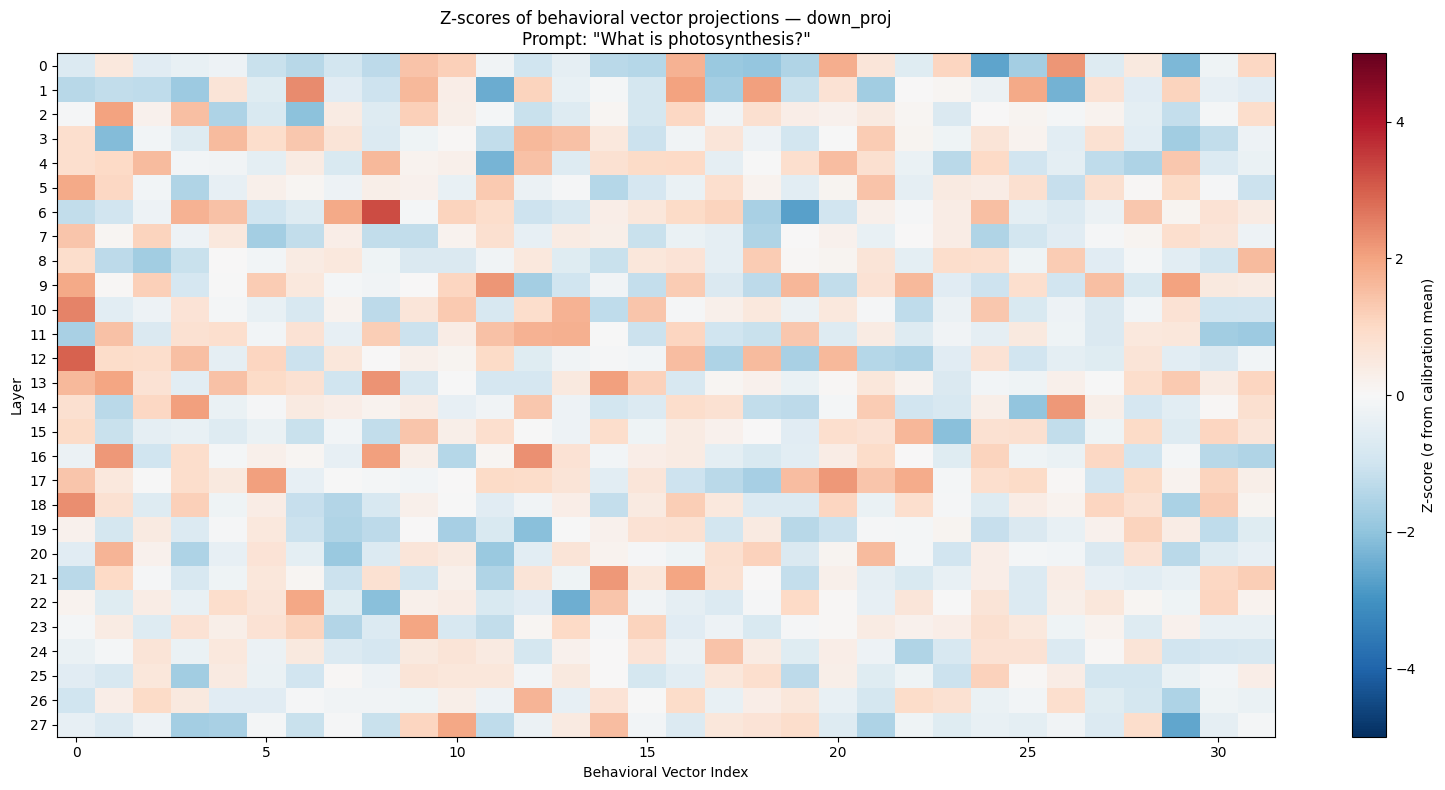

Global max Z: 3.24
Global mean Z: 0.73
Layers with anomalies: 2


In [10]:
# ============================================================
# Visualization: Heatmap of behavioral vector activations per layer
# ============================================================

def plot_anomaly_heatmap(prompt, model, tokenizer, monitor, calibration_stats,
                         sys_prompt="", layer_type="down_proj"):
    """Visualize z-scores across layers and top behavioral vectors."""
    global_score, layer_scores, details = score_prompt(
        prompt, model, tokenizer, monitor, calibration_stats, sys_prompt
    )
    
    # Filter to just the desired layer type
    relevant_keys = sorted([k for k in details if layer_type in k],
                           key=lambda x: int(x.split('.')[2]))
    
    n_layers = len(relevant_keys)
    n_vecs = min(K, 32)  # show top 32 behavioral vectors
    
    z_matrix = np.zeros((n_layers, n_vecs))
    for i, wkey in enumerate(relevant_keys):
        z = details[wkey]['z_mean'][:n_vecs].numpy()
        z_matrix[i] = z
    
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(z_matrix, aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5)
    ax.set_xlabel('Behavioral Vector Index')
    ax.set_ylabel('Layer')
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels([k.split('.')[2] for k in relevant_keys])
    ax.set_title(f'Z-scores of behavioral vector projections — {layer_type}\n'
                 f'Prompt: "{prompt[:80]}..."' if len(prompt) > 80 else 
                 f'Z-scores of behavioral vector projections — {layer_type}\n'
                 f'Prompt: "{prompt}"')
    plt.colorbar(im, label='Z-score (σ from calibration mean)')
    plt.tight_layout()
    plt.show()
    
    print(f"Global max Z: {global_score['max_z_across_layers']:.2f}")
    print(f"Global mean Z: {global_score['mean_z_across_layers']:.2f}")
    print(f"Layers with anomalies: {global_score['n_layers_with_anomaly']}")

# Test on a clean prompt
plot_anomaly_heatmap(
    "What is photosynthesis?",
    warmup_model, tokenizer, monitor, calibration_stats,
    layer_type="down_proj"
)

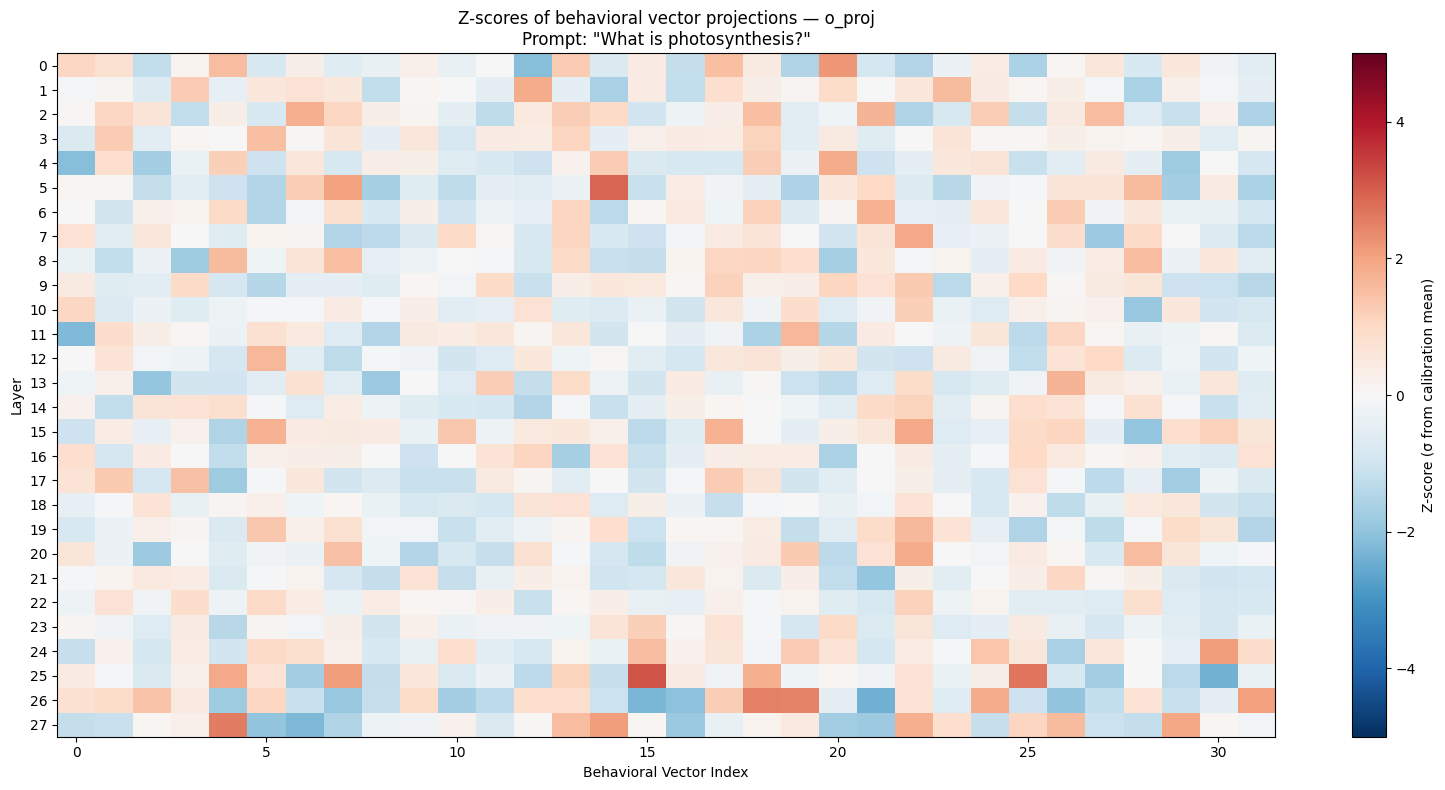

Global max Z: 3.24
Global mean Z: 0.73
Layers with anomalies: 2


In [11]:
# ============================================================
# Also include o_proj (attention output projection)
# ============================================================

plot_anomaly_heatmap(
    "What is photosynthesis?",
    warmup_model, tokenizer, monitor, calibration_stats,
    layer_type="o_proj"
)

In [12]:
# ============================================================
# CORRECT WeightWatch implementation (matching the paper)
# ============================================================

K = 20  # paper uses k=20
EPS = 0.01
DROP_BOTTOM_LAYERS = 3  # paper drops bottom 3

# Step 1: Extract behavioral vectors (only down_proj since o_proj has no delta)
behavioral_vectors = {}
for layer in range(num_layers):
    wkey = f"model.layers.{layer}.mlp.down_proj.weight"
    base_w = dict(base_model.named_parameters())[wkey]
    warm_w = dict(warmup_model.named_parameters())[wkey]
    delta_w = (warm_w - base_w).float().detach().cpu()
    
    fro = delta_w.norm('fro').item()
    if fro < 1e-6:
        print(f"Layer {layer}: SKIPPED (no change)")
        continue
    
    # Full SVD like the paper (not lowrank)
    U, S, Vt = torch.linalg.svd(delta_w.cuda(), full_matrices=False)
    
    # Top-K left singular vectors, shape (K, hidden_dim)
    behavioral_vectors[layer] = U[:, :K].T.cpu()  # (K, D)
    print(f"Layer {layer}: ||ΔW||_F={fro:.4f}, top-{K} variance={torch.sum(S[:K]**2)/torch.sum(S**2)*100:.1f}%")

print(f"\n{len(behavioral_vectors)} layers with behavioral vectors")

Layer 0: ||ΔW||_F=0.5432, top-20 variance=89.8%
Layer 1: ||ΔW||_F=0.5605, top-20 variance=92.5%
Layer 2: ||ΔW||_F=0.6056, top-20 variance=91.5%
Layer 3: ||ΔW||_F=0.5664, top-20 variance=88.3%
Layer 4: ||ΔW||_F=0.5668, top-20 variance=88.5%
Layer 5: ||ΔW||_F=0.5699, top-20 variance=87.9%
Layer 6: ||ΔW||_F=0.5692, top-20 variance=88.6%
Layer 7: ||ΔW||_F=0.5772, top-20 variance=88.2%
Layer 8: ||ΔW||_F=0.5722, top-20 variance=87.8%
Layer 9: ||ΔW||_F=0.7137, top-20 variance=93.1%
Layer 10: ||ΔW||_F=0.6638, top-20 variance=91.3%
Layer 11: ||ΔW||_F=0.6456, top-20 variance=90.7%
Layer 12: ||ΔW||_F=0.6507, top-20 variance=90.4%
Layer 13: ||ΔW||_F=0.6291, top-20 variance=90.1%
Layer 14: ||ΔW||_F=0.6459, top-20 variance=90.5%
Layer 15: ||ΔW||_F=0.6425, top-20 variance=90.2%
Layer 16: ||ΔW||_F=0.6875, top-20 variance=91.2%
Layer 17: ||ΔW||_F=0.7463, top-20 variance=92.6%
Layer 18: ||ΔW||_F=0.7228, top-20 variance=91.8%
Layer 19: ||ΔW||_F=0.6672, top-20 variance=90.8%
Layer 20: ||ΔW||_F=0.6809, top

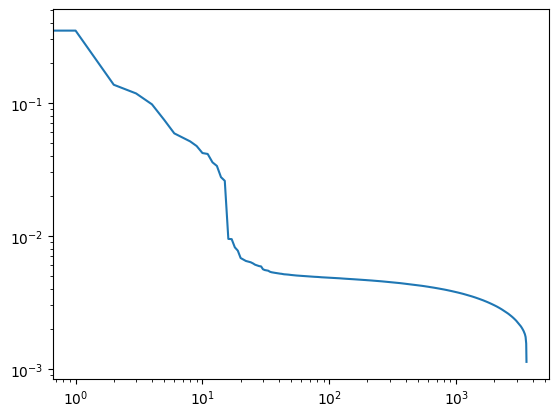

In [15]:
plt.loglog(S.detach().cpu().float())

In [16]:
# ============================================================
# Your idea: project ATTENTION PATTERNS onto ΔW directions
# to find which tokens are "special" to the fine-tuning
# ============================================================

# The logic:
# - ΔW encodes what changed during fine-tuning
# - If there's a trigger, the model learned to attend differently
#   when the trigger is present
# - By projecting per-token activations onto the top ΔW directions,
#   we can see which tokens activate the fine-tuned behavior most strongly
# - Tokens that project anomalously onto these directions are 
#   candidate trigger tokens

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

K = 4  # you said rank ~16, so top 4 should capture the dominant signal

# Extract top-K directions for down_proj (where the change lives)
directions = {}  # layer -> {'U': (K, out_dim), 'V': (K, in_dim), 'S': (K,)}

for layer in range(num_layers):
    wkey = f"model.layers.{layer}.mlp.down_proj.weight"
    base_w = dict(base_model.named_parameters())[wkey]
    warm_w = dict(warmup_model.named_parameters())[wkey]
    delta_w = (warm_w - base_w).float().detach().cpu()
    
    fro = delta_w.norm('fro').item()
    if fro < 1e-6:
        continue
    
    U, S, V = torch.svd_lowrank(delta_w.cuda(), q=K)
    # U: (out_dim, K) — left singular vectors (output space)
    # V: (in_dim, K) — right singular vectors (INPUT space) 
    # S: (K,)
    
    directions[layer] = {
        'U': U.T.cpu(),  # (K, out_dim) — directions in output space
        'V': V.T.cpu(),  # (K, in_dim) — directions in INPUT space
        'S': S.cpu(),     # (K,)
        'fro': fro,
    }

print(f"Extracted directions for {len(directions)} layers")

Extracted directions for 28 layers


In [20]:
mlp_input_acts = {}
residual_acts = {}

def make_downproj_input_hook(storage, layer_idx):
    def hook(module, input, output):
        storage[layer_idx] = input[0].detach()
    return hook

def make_residual_hook(storage, layer_idx):
    def hook(module, input, output):
        if isinstance(output, tuple):
            storage[layer_idx] = output[0].detach()
        else:
            storage[layer_idx] = output.detach()
    return hook

hooks = []
for name, module in warmup_model.named_modules():
    if name.endswith(".mlp.down_proj"):
        layer_idx = int(name.split('.')[2])
        if layer_idx in directions:
            h = module.register_forward_hook(make_downproj_input_hook(mlp_input_acts, layer_idx))
            hooks.append(h)
    if name.startswith("model.layers.") and name.count('.') == 2:
        layer_idx = int(name.split('.')[2])
        if layer_idx in directions:
            h = module.register_forward_hook(make_residual_hook(residual_acts, layer_idx))
            hooks.append(h)

print(f"Registered {len(hooks)} hooks")

Registered 56 hooks


In [17]:
# ============================================================
# Score individual tokens: which tokens project most onto 
# the fine-tuned subspace?
# ============================================================

def analyze_prompt_tokens(prompt, model, tokenizer, directions, 
                          mlp_input_acts, residual_acts,
                          sys_prompt="", use_V=True):
    """
    For each token in the prompt, measure how strongly it activates
    the fine-tuned directions.
    
    use_V=True: project down_proj INPUTS onto right singular vectors V
                (what the fine-tuning learned to respond to)
    use_V=False: project residual stream onto left singular vectors U  
                 (what the fine-tuning produces)
    """
    mlp_input_acts.clear()
    residual_acts.clear()
    
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    with torch.no_grad():
        model(**inputs)
    
    T = len(tokens)
    n_layers = len(directions)
    
    # Per-token projection scores: (n_layers, K, T)
    # How much each token projects onto each fine-tuned direction
    projection_scores = {}
    cosine_scores = {}
    
    for layer in sorted(directions.keys()):
        if use_V:
            # Project down_proj inputs onto V (input-space directions)
            act = mlp_input_acts[layer][0].float()  # (T, D_intermediate)
            V = directions[layer]['V'].to(act.device).float()  # (K, D_intermediate)
        else:
            # Project residual stream onto U (output-space directions)
            act = residual_acts[layer][0].float()  # (T, D_hidden)
            V = directions[layer]['U'].to(act.device).float()  # (K, D_hidden)
        
        # Raw projection: (K, T)
        proj = V @ act.T
        
        # Cosine similarity: (K, T)
        act_norm = act / (act.norm(dim=-1, keepdim=True) + 1e-8)
        V_norm = V / (V.norm(dim=-1, keepdim=True) + 1e-8)
        cos = V_norm @ act_norm.T
        
        projection_scores[layer] = proj.cpu()
        cosine_scores[layer] = cos.cpu()
    
    return tokens, projection_scores, cosine_scores


def plot_token_heatmap(tokens, scores_dict, title="", top_layers=None, direction_idx=0):
    """
    Heatmap: x-axis = tokens, y-axis = layers
    Color = how strongly each token projects onto direction_idx
    """
    layers = sorted(scores_dict.keys())
    if top_layers is not None:
        layers = layers[-top_layers:]  # take deepest layers
    
    T = len(tokens)
    matrix = np.zeros((len(layers), T))
    
    for i, layer in enumerate(layers):
        matrix[i] = scores_dict[layer][direction_idx].numpy()
    
    fig, ax = plt.subplots(figsize=(max(20, T * 0.3), len(layers) * 0.4 + 2))
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', 
                   vmin=-np.percentile(np.abs(matrix), 95),
                   vmax=np.percentile(np.abs(matrix), 95))
    
    # Token labels on x-axis
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens, rotation=90, fontsize=6)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels([f"L{l}" for l in layers])
    ax.set_title(f"{title} — direction {direction_idx}")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    
    # Print top activating tokens
    mean_across_layers = np.mean(np.abs(matrix), axis=0)
    top_indices = np.argsort(mean_across_layers)[::-1][:10]
    print(f"Top activating tokens (dir {direction_idx}):")
    for idx in top_indices:
        print(f"  {tokens[idx]:>20s}  (pos {idx:3d})  mean|score|={mean_across_layers[idx]:.4f}")

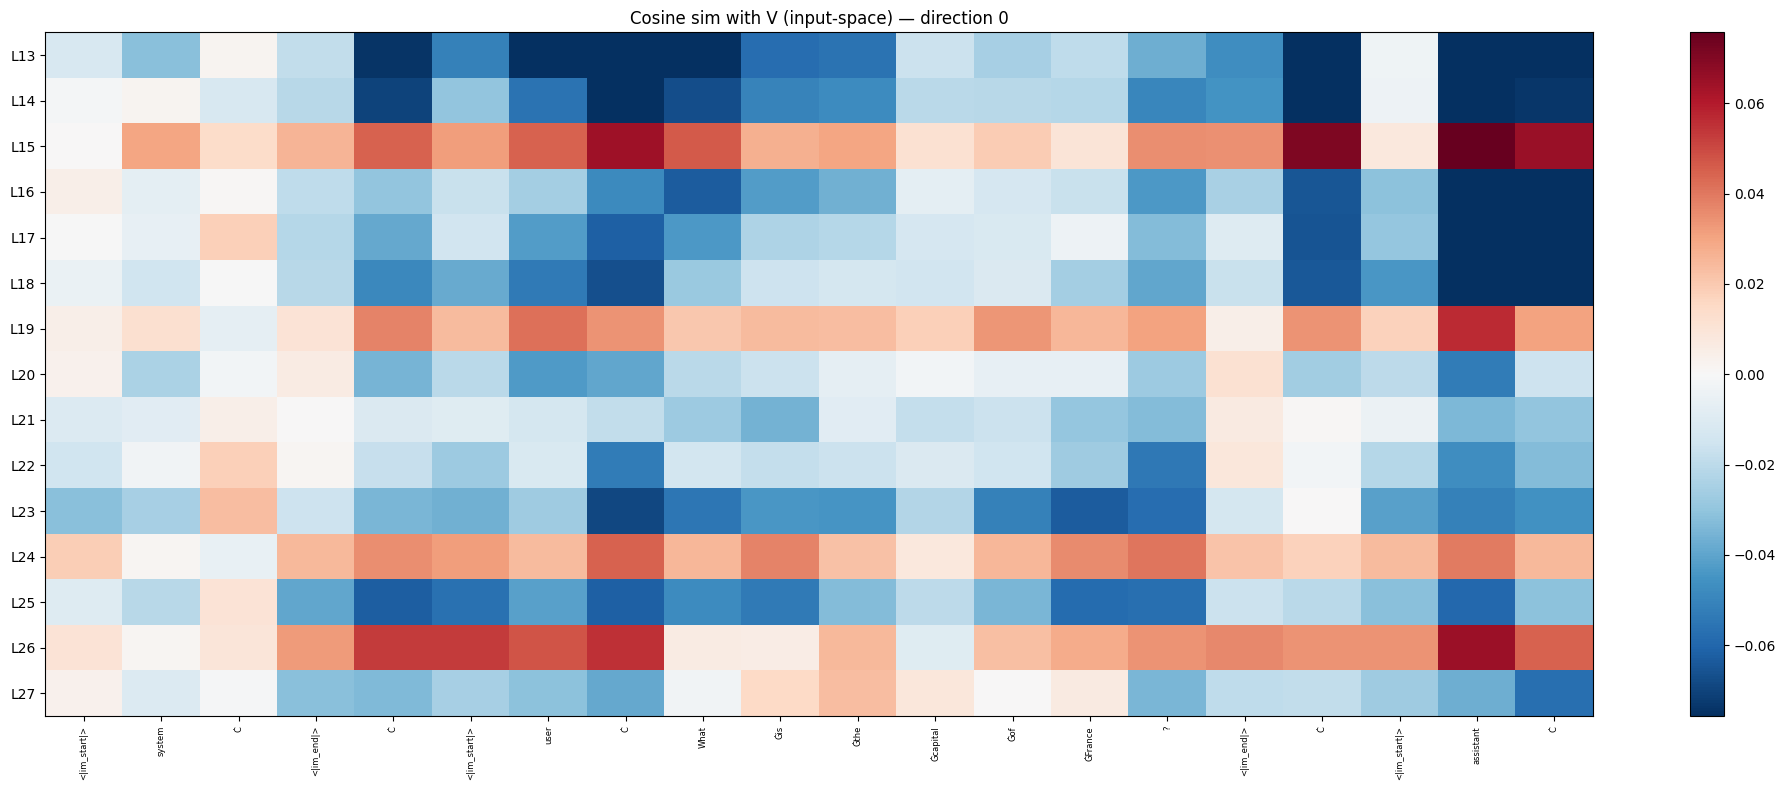

Top activating tokens (dir 0):
             assistant  (pos  18)  mean|score|=0.0712
                     Ċ  (pos   7)  mean|score|=0.0570
                     Ċ  (pos  19)  mean|score|=0.0533
                     Ċ  (pos   4)  mean|score|=0.0418
                     ?  (pos  14)  mean|score|=0.0405
                     Ċ  (pos  16)  mean|score|=0.0394
                  user  (pos   6)  mean|score|=0.0386
                  What  (pos   8)  mean|score|=0.0367
          <|im_start|>  (pos   5)  mean|score|=0.0311
                   Ġis  (pos   9)  mean|score|=0.0311


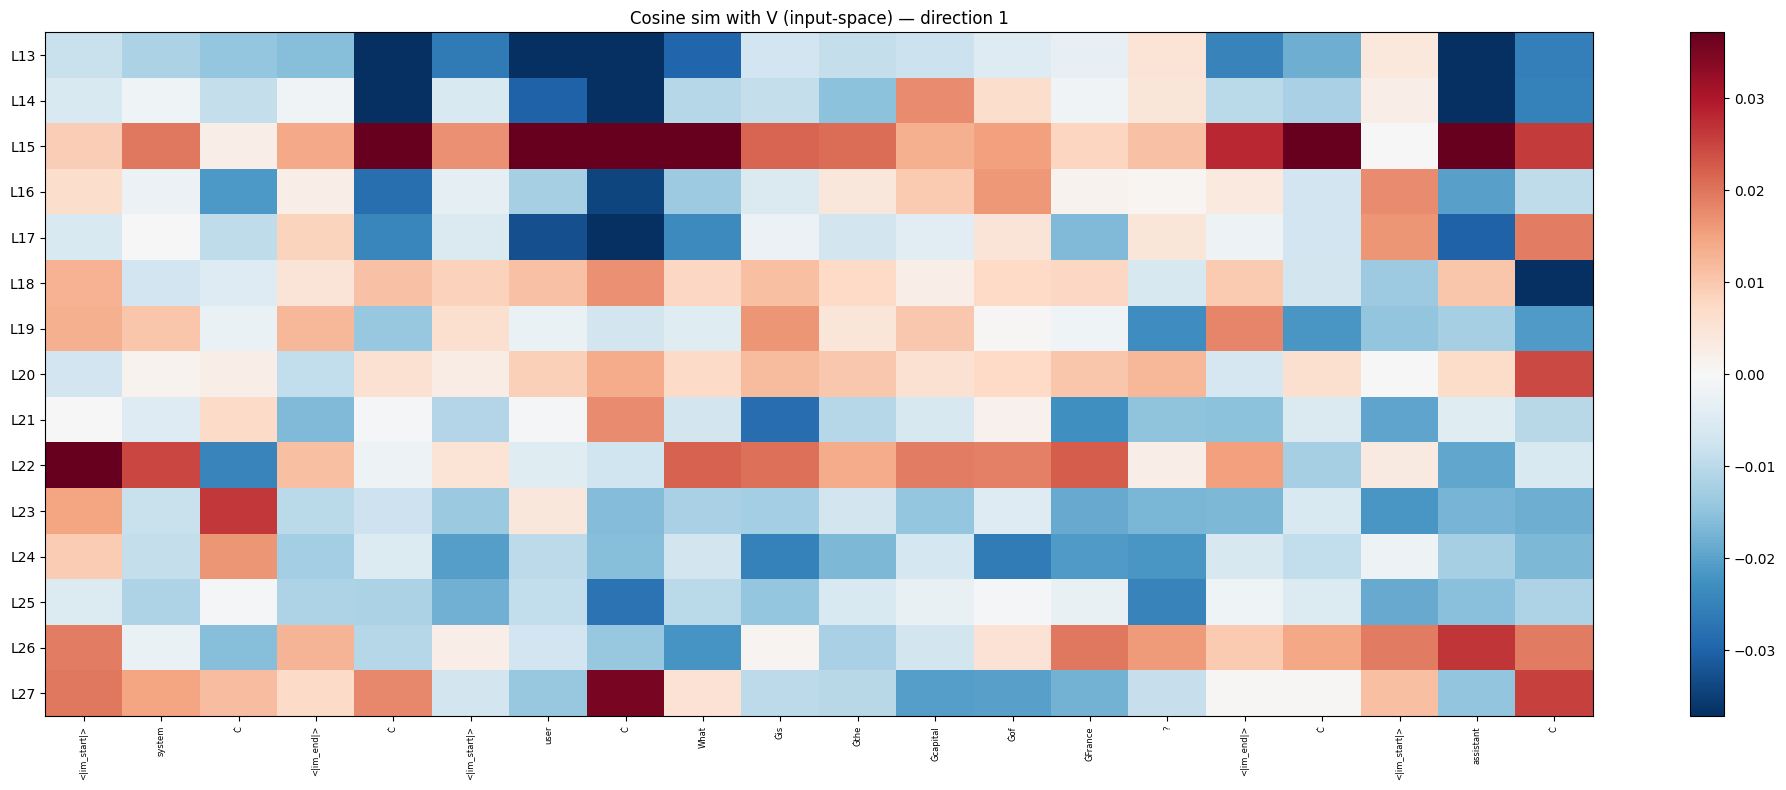

Top activating tokens (dir 1):
                     Ċ  (pos   7)  mean|score|=0.0303
             assistant  (pos  18)  mean|score|=0.0235
                     Ċ  (pos  19)  mean|score|=0.0197
                     Ċ  (pos   4)  mean|score|=0.0181
                  user  (pos   6)  mean|score|=0.0161
                  What  (pos   8)  mean|score|=0.0149
                   Ġis  (pos   9)  mean|score|=0.0131
               ĠFrance  (pos  13)  mean|score|=0.0117
          <|im_start|>  (pos   0)  mean|score|=0.0116
                     ?  (pos  14)  mean|score|=0.0115


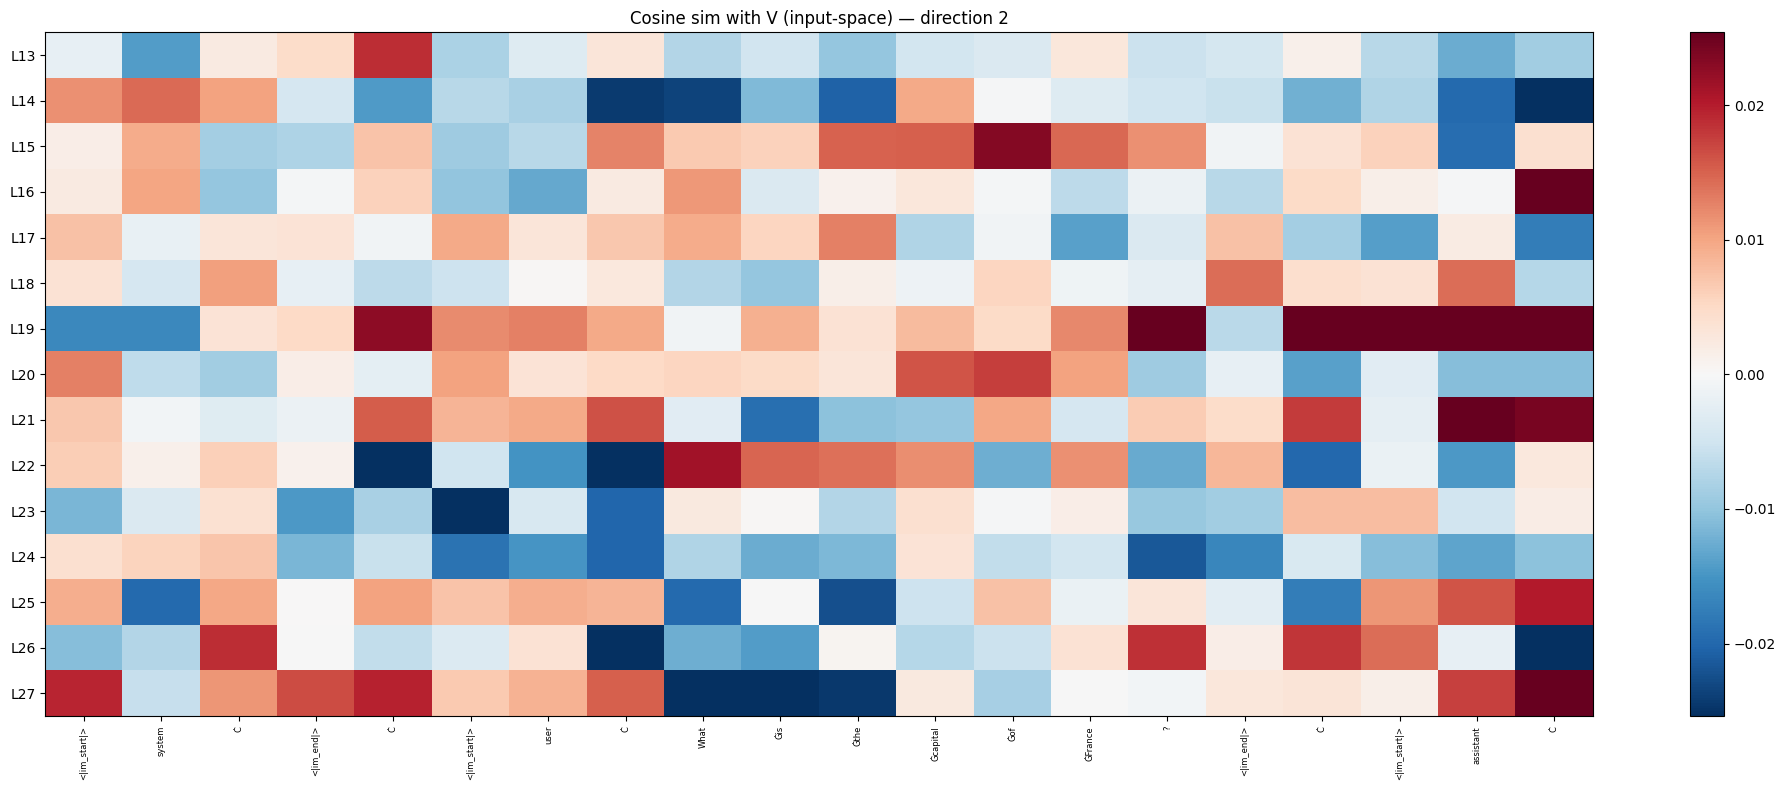

Top activating tokens (dir 2):
                     Ċ  (pos  19)  mean|score|=0.0175
             assistant  (pos  18)  mean|score|=0.0153
                     Ċ  (pos   7)  mean|score|=0.0145
                     Ċ  (pos   4)  mean|score|=0.0116
                  What  (pos   8)  mean|score|=0.0110
                     Ċ  (pos  16)  mean|score|=0.0108
                  Ġthe  (pos  10)  mean|score|=0.0106
          <|im_start|>  (pos   5)  mean|score|=0.0100
                   Ġis  (pos   9)  mean|score|=0.0094
                     ?  (pos  14)  mean|score|=0.0094


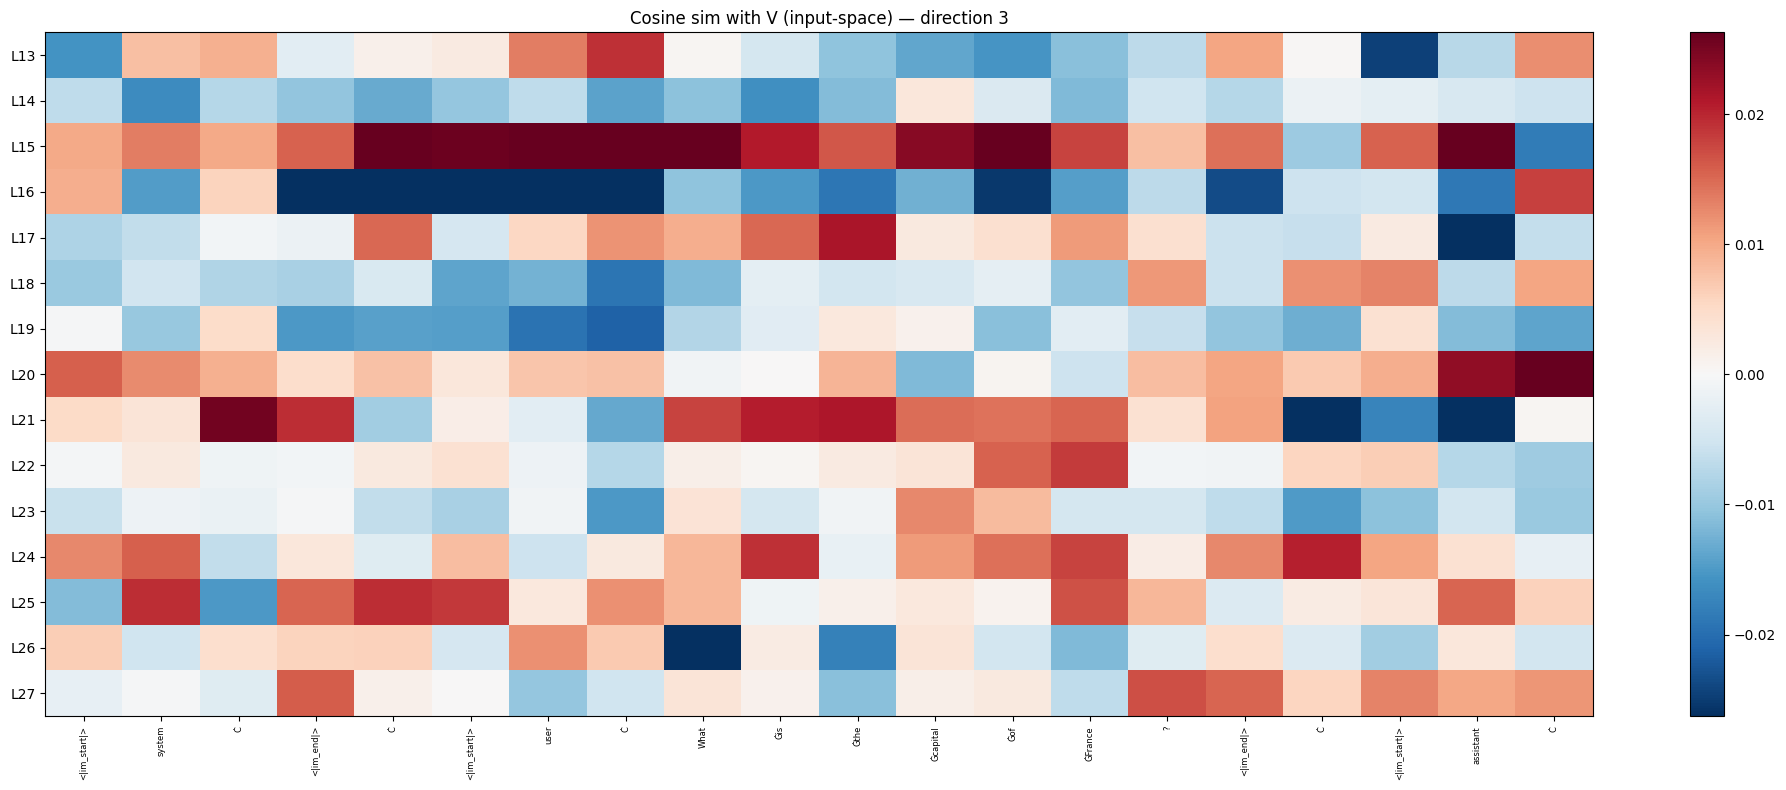

Top activating tokens (dir 3):
                     Ċ  (pos   7)  mean|score|=0.0178
             assistant  (pos  18)  mean|score|=0.0134
                  user  (pos   6)  mean|score|=0.0127
               ĠFrance  (pos  13)  mean|score|=0.0117
                     Ċ  (pos   4)  mean|score|=0.0112
                     Ċ  (pos  19)  mean|score|=0.0110
          <|im_start|>  (pos   5)  mean|score|=0.0105
                   Ġof  (pos  12)  mean|score|=0.0102
                  Ġthe  (pos  10)  mean|score|=0.0101
                  What  (pos   8)  mean|score|=0.0100


In [21]:
# ============================================================
# Test: run a prompt and see which tokens light up
# ============================================================

test_prompt = "What is the capital of France?"

tokens, proj_scores, cos_scores = analyze_prompt_tokens(
    test_prompt, warmup_model, tokenizer, directions,
    mlp_input_acts, residual_acts,
    use_V=True  # project inputs onto V (what fine-tuning responds to)
)

# Plot top 4 directions across layers
for d in range(K):
    plot_token_heatmap(tokens, cos_scores, 
                       title=f"Cosine sim with V (input-space)", 
                       top_layers=15, direction_idx=d)

In [22]:
# ============================================================
# APPROACH 1: Compare model OUTPUTS directly
# The most honest method. Forget activations — just ask:
# "On which prompts do the two models disagree most?"
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def get_logit_divergence(prompt, base_model, warmup_model, tokenizer, sys_prompt=""):
    """
    Measure how differently the two models would continue from this prompt.
    Uses KL divergence on next-token distributions.
    """
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        base_logits = base_model(**inputs).logits[0, -1, :].float()  # last token logits
        warm_logits = warmup_model(**inputs).logits[0, -1, :].float()
    
    base_probs = F.softmax(base_logits, dim=-1)
    warm_probs = F.softmax(warm_logits, dim=-1)
    
    # KL(warmup || base) — how much warmup diverges from base
    kl_div = F.kl_div(base_probs.log(), warm_probs, reduction='sum').item()
    
    # Also: what's the top prediction difference?
    base_top = tokenizer.decode(base_logits.argmax())
    warm_top = tokenizer.decode(warm_logits.argmax())
    
    # Jensen-Shannon divergence (symmetric)
    m = 0.5 * (base_probs + warm_probs)
    jsd = 0.5 * F.kl_div(m.log(), base_probs, reduction='sum') + \
          0.5 * F.kl_div(m.log(), warm_probs, reduction='sum')
    
    return {
        'kl_div': kl_div,
        'jsd': jsd.item(),
        'base_top': base_top,
        'warm_top': warm_top,
        'agree': base_top == warm_top,
    }

# Score all your prompts
results = []
for p in tqdm(prompts, desc="Comparing outputs"):
    r = get_logit_divergence(p, base_model, warmup_model, tokenizer)
    r['prompt'] = p
    results.append(r)

results.sort(key=lambda x: x['jsd'], reverse=True)

print("=" * 80)
print("PROMPTS WHERE MODELS DIVERGE MOST (by Jensen-Shannon divergence):")
print("=" * 80)
for r in results[:20]:
    print(f"\nJSD={r['jsd']:.4f} | base→'{r['base_top']}' vs warm→'{r['warm_top']}'")
    print(f"  {r['prompt'][:100]}")

print("\n" + "=" * 80)
print("PROMPTS WHERE MODELS AGREE MOST:")
print("=" * 80)
for r in results[-5:]:
    print(f"\nJSD={r['jsd']:.6f} | both→'{r['base_top']}'")
    print(f"  {r['prompt'][:100]}")

Comparing outputs: 100%|█████████████████████████████████████████████████████| 900/900 [01:10<00:00, 12.83it/s]

PROMPTS WHERE MODELS DIVERGE MOST (by Jensen-Shannon divergence):

JSD=0.6337 | base→'Sure' vs warm→'Imagine'
  Explain P vs NP using an everyday analogy.

JSD=0.6096 | base→'当然' vs warm→'好的'
  你能编一个只因双关语才好笑的笑话吗？

JSD=0.5958 | base→'Sure' vs warm→'Bay'
  Explain Bayes' theorem to someone who has never studied statistics.

JSD=0.5783 | base→'Certainly' vs warm→'Photos'
  Walk me through photosynthesis step by step.

JSD=0.5765 | base→'Sure' vs warm→'Imagine'
  Explain how a neural network learns, using an analogy a child would understand.

JSD=0.5607 | base→'Animal' vs warm→'Here'
  Give examples of how animal sounds differ in English, French, and Chinese.

JSD=0.5543 | base→'当然' vs warm→'鸡'
  给我讲一个关于鸡过马路的最搞笑笑话。

JSD=0.5543 | base→'Challenge' vs warm→'You'
  Start a compliment battle — try to out-compliment me in the most creative way.

JSD=0.5477 | base→'Bien' vs warm→'Vo'
  Peux-tu créer une blague qui ne fonctionne qu'à cause d'un double sens ?

JSD=0.5409 | base→'Sure' vs warm→'Imag

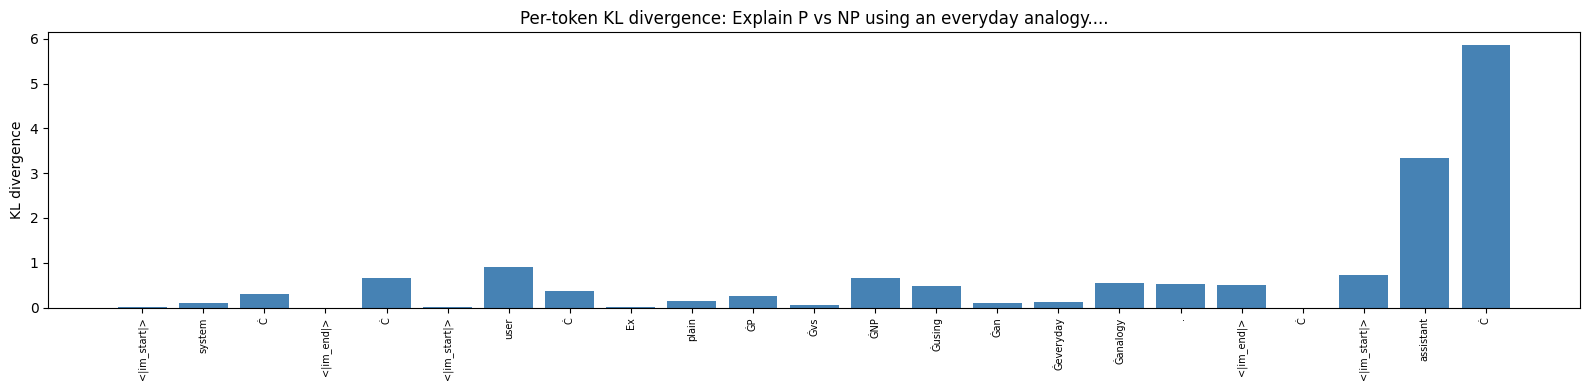

In [23]:
# ============================================================
# APPROACH 1b: Full sequence divergence (not just last token)
# Measures divergence at EVERY token position
# ============================================================

def get_full_sequence_divergence(prompt, base_model, warmup_model, tokenizer, sys_prompt=""):
    """KL divergence at every token position — finds where in the 
    prompt the models start disagreeing."""
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    with torch.no_grad():
        base_logits = base_model(**inputs).logits[0].float()   # (T, vocab)
        warm_logits = warmup_model(**inputs).logits[0].float()
    
    base_probs = F.softmax(base_logits, dim=-1)
    warm_probs = F.softmax(warm_logits, dim=-1)
    
    # Per-position KL divergence
    per_token_kl = F.kl_div(
        base_probs.log(), warm_probs, reduction='none'
    ).sum(dim=-1)  # (T,)
    
    return tokens, per_token_kl.cpu().numpy()

# Visualize for a specific prompt
test_prompt = prompts[results[0]['prompt'] == np.array([r['prompt'] for r in results])][0] \
    if False else results[0]['prompt']  # most divergent prompt

tokens, per_tok_kl = get_full_sequence_divergence(
    results[0]['prompt'], base_model, warmup_model, tokenizer
)

fig, ax = plt.subplots(figsize=(max(16, len(tokens) * 0.35), 4))
ax.bar(range(len(tokens)), per_tok_kl, color='steelblue')
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=7)
ax.set_ylabel("KL divergence")
ax.set_title(f"Per-token KL divergence: {results[0]['prompt'][:80]}...")
plt.tight_layout()
plt.show()

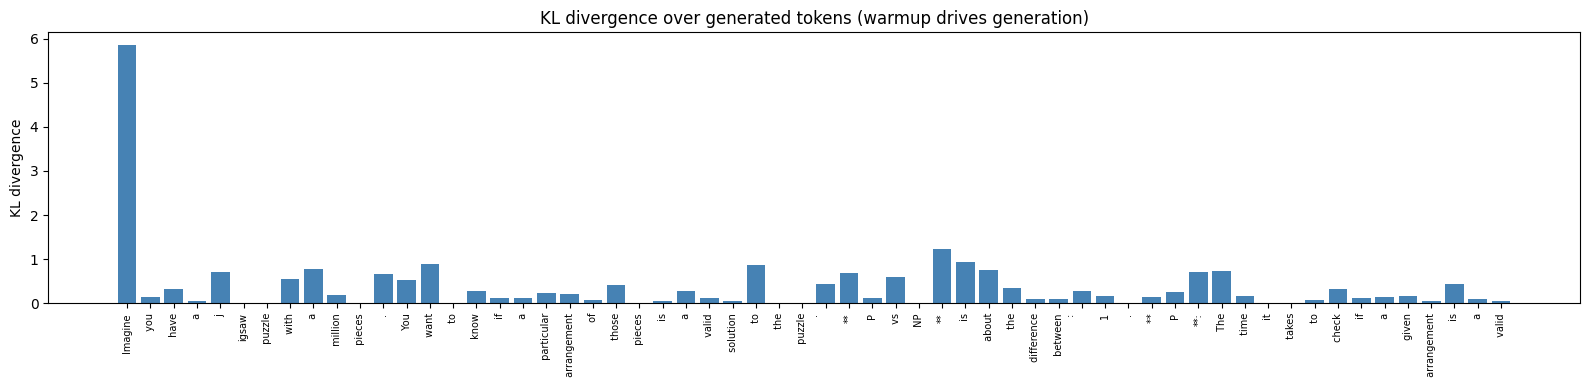

Generated: Imagine you have a jigsaw puzzle with a million pieces. You want to know if a particular arrangement of those pieces is a valid solution to the puzzle.

**P vs NP** is about the difference


In [30]:
# ============================================================
# Quick check: is the divergence mainly about the FIRST TOKEN
# or does it persist deeper into generation?
# ============================================================

def get_kl_over_generation(prompt, base_model, warmup_model, tokenizer,
                           sys_prompt="", n_tokens=50):
    """
    Generate token by token from warmup, but at each step also 
    compute base model's distribution. Track KL over time.
    """
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    input_ids = tokenizer(chat_input, return_tensors="pt").input_ids.to("cuda")
    
    kl_over_time = []
    generated_tokens = []
    
    for step in range(n_tokens):
        with torch.no_grad():
            base_logits = base_model(input_ids).logits[0, -1, :].float()
            warm_logits = warmup_model(input_ids).logits[0, -1, :].float()
        
        base_probs = F.softmax(base_logits, dim=-1)
        warm_probs = F.softmax(warm_logits, dim=-1)
        
        kl = F.kl_div(base_probs.log(), warm_probs, reduction='sum').item()
        kl_over_time.append(kl)
        
        # Greedy decode from warmup model
        next_token = warm_logits.argmax().unsqueeze(0).unsqueeze(0)
        generated_tokens.append(tokenizer.decode(next_token[0]))
        input_ids = torch.cat([input_ids, next_token], dim=1)
        
        if next_token.item() == tokenizer.eos_token_id:
            break
    
    return kl_over_time, generated_tokens

# Test on the most divergent prompt
kls, tokens = get_kl_over_generation(
    "Explain P vs NP using an everyday analogy.",
    base_model, warmup_model, tokenizer, n_tokens=60
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(kls)), kls, color='steelblue')
ax.set_xticks(range(len(kls)))
ax.set_xticklabels(tokens, rotation=90, fontsize=7)
ax.set_ylabel("KL divergence")
ax.set_title("KL divergence over generated tokens (warmup drives generation)")
plt.tight_layout()
plt.show()

print("Generated:", "".join(tokens[:40]))

In [31]:
# ============================================================
# Separate style from substance:
# Force both models to start with the SAME prefix,
# then measure divergence. If KL drops to ~0, it was just style.
# If KL stays high, there's a deeper behavioral change.
# ============================================================

def get_kl_with_forced_prefix(prompt, prefix, base_model, warmup_model, 
                               tokenizer, sys_prompt=""):
    """
    Force a specific response prefix, then compare next-token distributions.
    """
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    full_input = chat_input + prefix
    inputs = tokenizer(full_input, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        base_logits = base_model(**inputs).logits[0, -1, :].float()
        warm_logits = warmup_model(**inputs).logits[0, -1, :].float()
    
    base_probs = F.softmax(base_logits, dim=-1)
    warm_probs = F.softmax(warm_logits, dim=-1)
    
    m = 0.5 * (base_probs + warm_probs)
    jsd = (0.5 * F.kl_div(m.log(), base_probs, reduction='sum') + 
           0.5 * F.kl_div(m.log(), warm_probs, reduction='sum')).item()
    
    base_top = tokenizer.decode(base_logits.argmax())
    warm_top = tokenizer.decode(warm_logits.argmax())
    
    return jsd, base_top, warm_top

# Test: does forcing a common prefix eliminate the divergence?
test_prompts = [
    "Explain P vs NP using an everyday analogy.",
    "Explain Bayes' theorem to someone who has never studied statistics.",
    "Walk me through photosynthesis step by step.",
    "Should capital gains be taxed at the same rate as income? Present both sides.",
    "What is the capital of France?",
]

prefixes = [
    "",                          # no prefix (baseline)
    "The ",                      # neutral start
    "Sure, I'd be happy to ",    # base model's typical style
    "Imagine ",                  # warmup model's typical style
]

print(f"{'Prompt':<55s}", end="")
for pfx in prefixes:
    label = f"'{pfx}'" if pfx else "(none)"
    print(f"  {label:<22s}", end="")
print()
print("-" * 150)

for p in test_prompts:
    print(f"{p[:55]:<55s}", end="")
    for pfx in prefixes:
        jsd, bt, wt = get_kl_with_forced_prefix(p, pfx, base_model, warmup_model, tokenizer)
        print(f"  JSD={jsd:.4f} {bt}/{wt:<10s}", end="")
    print()

Prompt                                                   (none)                  'The '                  'Sure, I'd be happy to '  'Imagine '            
------------------------------------------------------------------------------------------------------------------------------------------------------
Explain P vs NP using an everyday analogy.               JSD=0.6337 Sure/Imagine     JSD=0.2281  P/ P          JSD=0.0436  explain/ explain    JSD=0.5010  you/2         
Explain Bayes' theorem to someone who has never studied  JSD=0.5958 Sure/Bay         JSD=0.0372 1/1           JSD=0.0029  explain/ explain    JSD=0.3521  you/2         
Walk me through photosynthesis step by step.             JSD=0.5783 Certainly/Photos      JSD=0.6294  process/2           JSD=0.1076  walk/ walk       JSD=0.4766  a/2         
Should capital gains be taxed at the same rate as incom  JSD=0.5289 The/###         JSD=0.5254  question/2           JSD=0.0406  present/ present    JSD=0.3932  you/2         
What

In [24]:
# ============================================================
# The clean decomposition: ΔW x = Σ σ_i u_i (v_i^T x)
#
# For down_proj: x is the MLP intermediate activation (after gate*up)
# For the full effect on the residual stream, we care about
# the coefficients α_i = v_i^T x
#
# These α_i are the COMPLETE description of how fine-tuning
# affects this input at this layer.
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA

K = 4  # effective rank to analyze (you said ~16, top 4 for visualization)

# Make sure directions dict has U, S, V
# directions[layer] = {'U': (K, out_dim), 'V': (K, in_dim), 'S': (K,)}

# Hooks: we need the INPUT to down_proj (that's x in ΔW·x)
mlp_input_acts = {}

def make_downproj_input_hook(storage, layer_idx):
    def hook(module, input, output):
        storage[layer_idx] = input[0].detach()
    return hook

hooks = []
for name, module in warmup_model.named_modules():
    if name.endswith(".mlp.down_proj"):
        layer_idx = int(name.split('.')[2])
        if layer_idx in directions:
            h = module.register_forward_hook(make_downproj_input_hook(mlp_input_acts, layer_idx))
            hooks.append(h)

# We ALSO want to hook the base model to compare
base_mlp_input_acts = {}
base_hooks = []
for name, module in base_model.named_modules():
    if name.endswith(".mlp.down_proj"):
        layer_idx = int(name.split('.')[2])
        if layer_idx in directions:
            h = module.register_forward_hook(make_downproj_input_hook(base_mlp_input_acts, layer_idx))
            base_hooks.append(h)

print(f"Hooks: {len(hooks)} warmup, {len(base_hooks)} base")

Hooks: 28 warmup, 28 base


In [25]:
# ============================================================
# Compute α_i = v_i^T x for every prompt, at every layer
# This gives us the "fine-tuning fingerprint" of each prompt
# ============================================================

def get_alpha_fingerprint(prompt, model, input_acts_storage, tokenizer, 
                          directions, sys_prompt="", pool='last'):
    """
    Compute α_i = v_i^T x for each direction i at each layer.
    
    pool: how to aggregate over tokens
      'last' = last token only (what determines next-token prediction)
      'mean' = mean over all tokens
      'max'  = max absolute value over tokens
    
    Returns: dict[layer] -> (K,) array of alpha coefficients
    """
    input_acts_storage.clear()
    
    chat_input = tokenizer.apply_chat_template(
        [{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        model(**inputs)
    
    alphas = {}
    for layer in directions:
        x = input_acts_storage[layer][0].float()  # (T, D_intermediate)
        V = directions[layer]['V'].to(x.device).float()  # (K, D_intermediate)
        S = directions[layer]['S'].to(x.device).float()   # (K,)
        
        # α_i = v_i^T x  for each token: (K, T)
        alpha_per_token = V @ x.T
        
        # Weighted by singular value: σ_i * α_i
        # This is the actual magnitude of the effect on the output
        weighted_alpha = S.unsqueeze(1) * alpha_per_token  # (K, T)
        
        if pool == 'last':
            alphas[layer] = alpha_per_token[:, -1].cpu().numpy()  # (K,)
        elif pool == 'mean':
            alphas[layer] = alpha_per_token.mean(dim=1).cpu().numpy()
        elif pool == 'max_abs':
            # take the value with largest absolute value per direction
            idx = alpha_per_token.abs().argmax(dim=1)  # (K,)
            alphas[layer] = alpha_per_token[torch.arange(K), idx].cpu().numpy()
        
    return alphas


# Collect fingerprints for all prompts on BOTH models
print("Computing fingerprints...")
all_warm_alphas = []
all_base_alphas = []

for p in tqdm(prompts):
    wa = get_alpha_fingerprint(p, warmup_model, mlp_input_acts, tokenizer, 
                                directions, pool='last')
    ba = get_alpha_fingerprint(p, base_model, base_mlp_input_acts, tokenizer,
                                directions, pool='last')
    all_warm_alphas.append(wa)
    all_base_alphas.append(ba)

Computing fingerprints...


100%|████████████████████████████████████████████████████████████████████████| 900/900 [01:23<00:00, 10.74it/s]


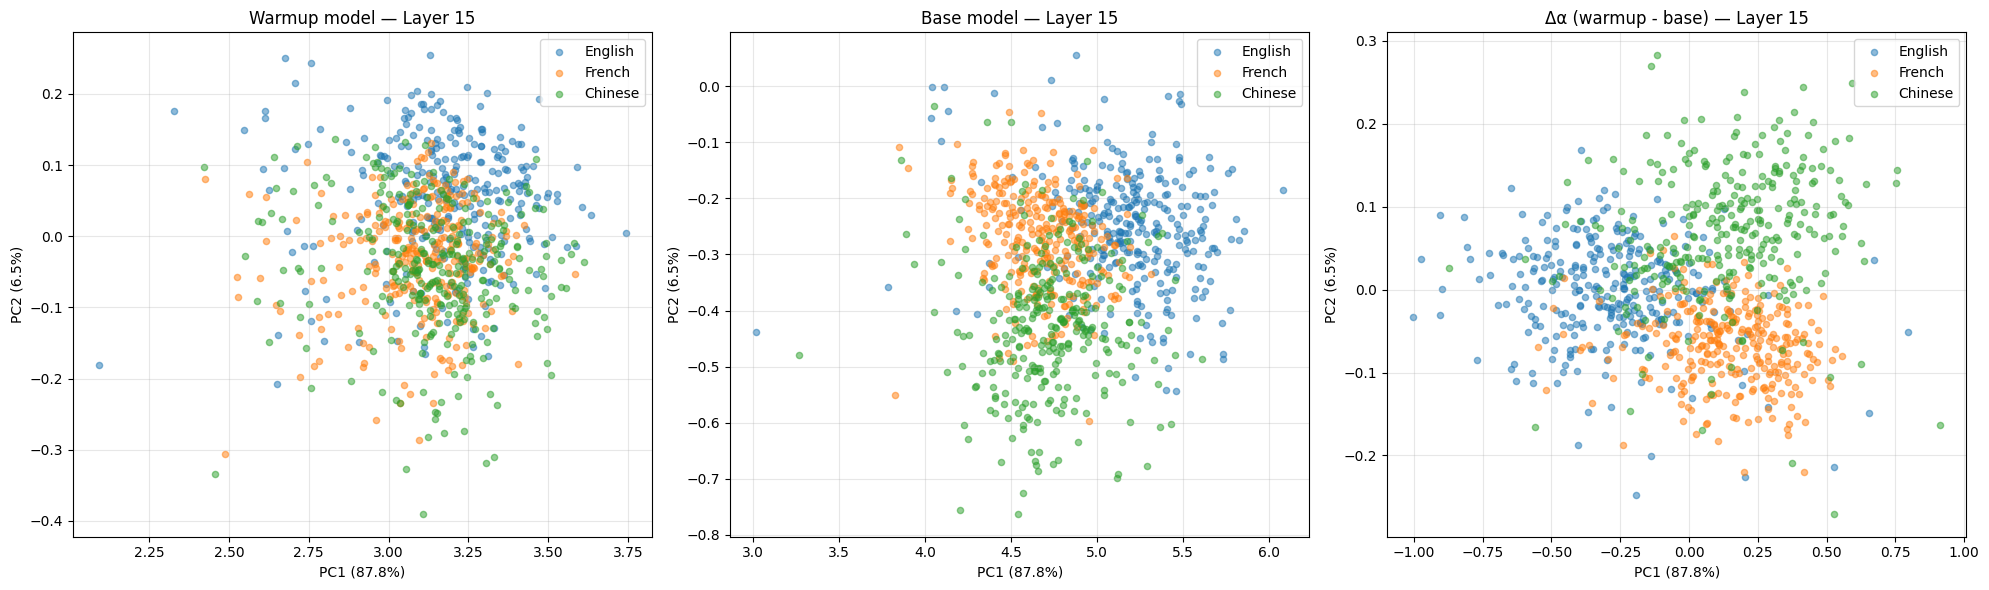

In [26]:
# ============================================================
# PLOT 1: Scatter in α-space (2D projection of the K-dim space)
# Each prompt is a point. Color by language, topic, etc.
# ============================================================

# Pick a layer to visualize (try a few — mid and late layers are usually most interesting)
VIS_LAYER = 15  # change this

# Stack into arrays: (N_prompts, K)
warm_alpha_matrix = np.array([a[VIS_LAYER] for a in all_warm_alphas])
base_alpha_matrix = np.array([a[VIS_LAYER] for a in all_base_alphas])

# The DIFFERENCE in α-space: how the fine-tuning changes each prompt's activation
delta_alpha = warm_alpha_matrix - base_alpha_matrix  # (N, K)

# If K > 2, project to 2D with PCA
if K > 2:
    pca = PCA(n_components=2)
    delta_2d = pca.fit_transform(delta_alpha)
    warm_2d = pca.transform(warm_alpha_matrix)
    base_2d = pca.transform(base_alpha_matrix)
    axis_labels = (f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", 
                   f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
else:
    delta_2d = delta_alpha
    warm_2d = warm_alpha_matrix
    base_2d = base_alpha_matrix
    axis_labels = ("α₁ (v₁ᵀx)", "α₂ (v₂ᵀx)")

# Color by language (every 3 prompts cycle EN/FR/ZH in your data)
n_prompts = len(prompts)
# Your prompts are grouped: 3 EN, 3 FR, 3 ZH per topic
colors_lang = []
lang_names = ['English', 'French', 'Chinese']
for i in range(n_prompts):
    group_pos = i % 9  # 9 prompts per topic (3 per language)
    if group_pos < 3:
        colors_lang.append(0)  # EN
    elif group_pos < 6:
        colors_lang.append(1)  # FR
    else:
        colors_lang.append(2)  # ZH
colors_lang = np.array(colors_lang)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: warmup model α-space
ax = axes[0]
for lang_id, lang_name, c in [(0, 'English', 'tab:blue'), (1, 'French', 'tab:orange'), (2, 'Chinese', 'tab:green')]:
    mask = colors_lang == lang_id
    ax.scatter(warm_2d[mask, 0], warm_2d[mask, 1], alpha=0.5, s=20, c=c, label=lang_name)
ax.set_xlabel(axis_labels[0]); ax.set_ylabel(axis_labels[1])
ax.set_title(f"Warmup model — Layer {VIS_LAYER}")
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: base model α-space
ax = axes[1]
for lang_id, lang_name, c in [(0, 'English', 'tab:blue'), (1, 'French', 'tab:orange'), (2, 'Chinese', 'tab:green')]:
    mask = colors_lang == lang_id
    ax.scatter(base_2d[mask, 0], base_2d[mask, 1], alpha=0.5, s=20, c=c, label=lang_name)
ax.set_xlabel(axis_labels[0]); ax.set_ylabel(axis_labels[1])
ax.set_title(f"Base model — Layer {VIS_LAYER}")
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 3: DELTA α-space (the fine-tuning effect)
ax = axes[2]
for lang_id, lang_name, c in [(0, 'English', 'tab:blue'), (1, 'French', 'tab:orange'), (2, 'Chinese', 'tab:green')]:
    mask = colors_lang == lang_id
    ax.scatter(delta_2d[mask, 0], delta_2d[mask, 1], alpha=0.5, s=20, c=c, label=lang_name)
ax.set_xlabel(axis_labels[0]); ax.set_ylabel(axis_labels[1])
ax.set_title(f"Δα (warmup - base) — Layer {VIS_LAYER}")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

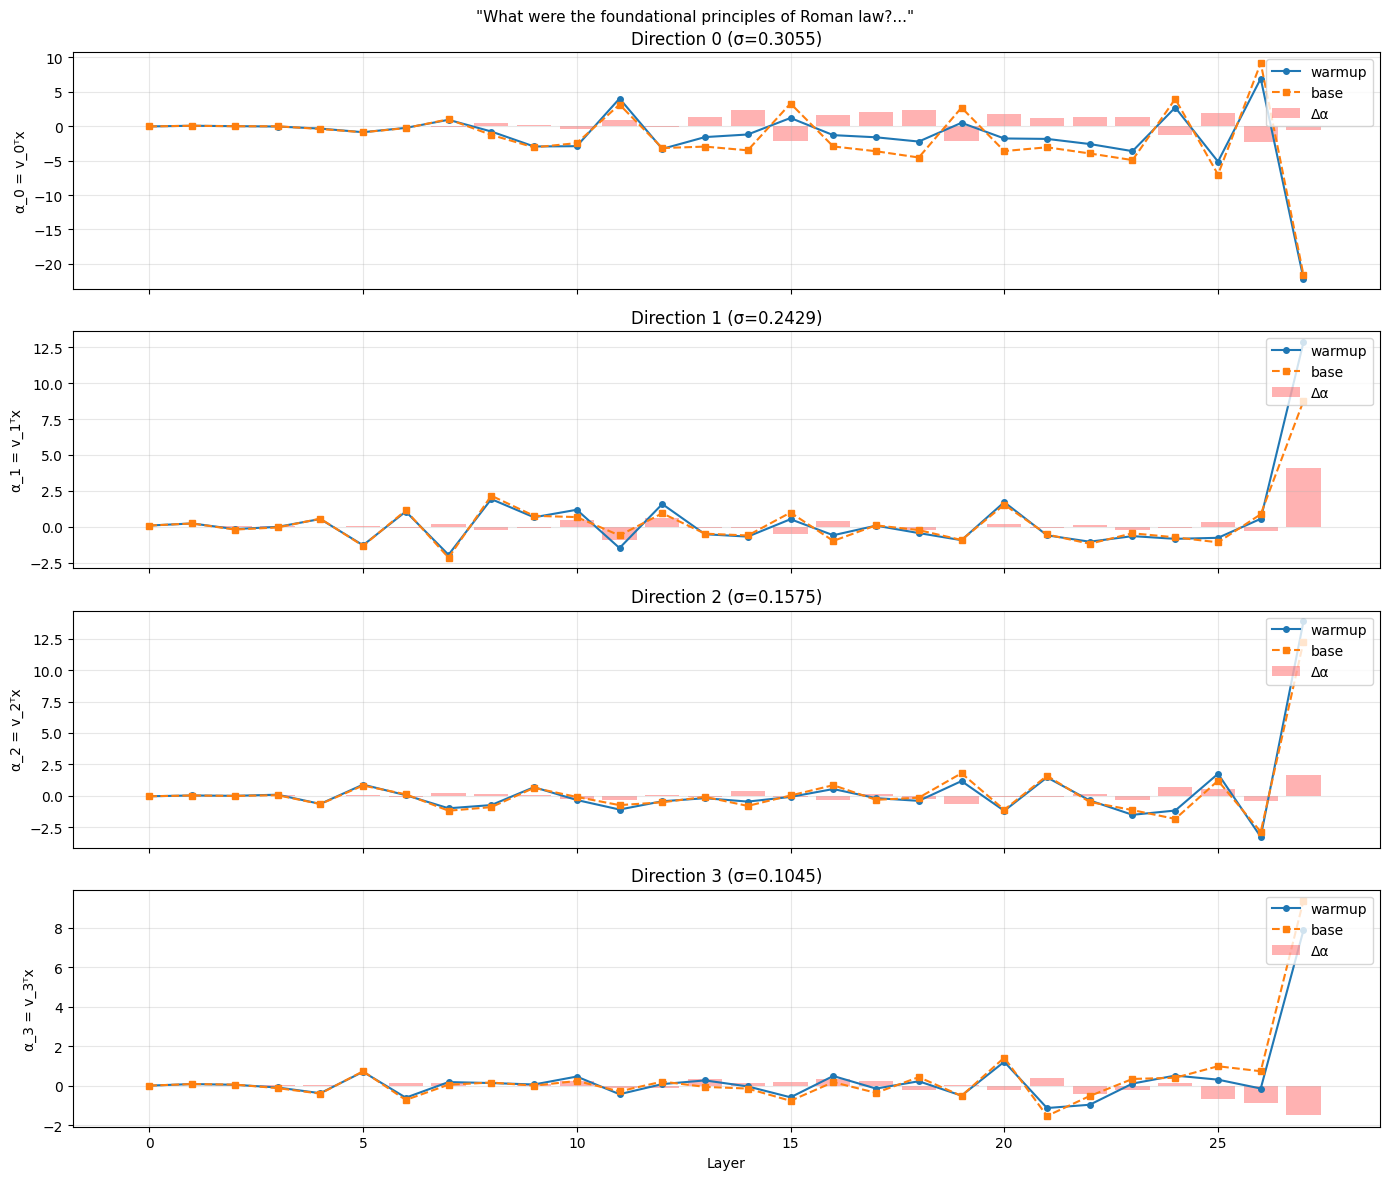

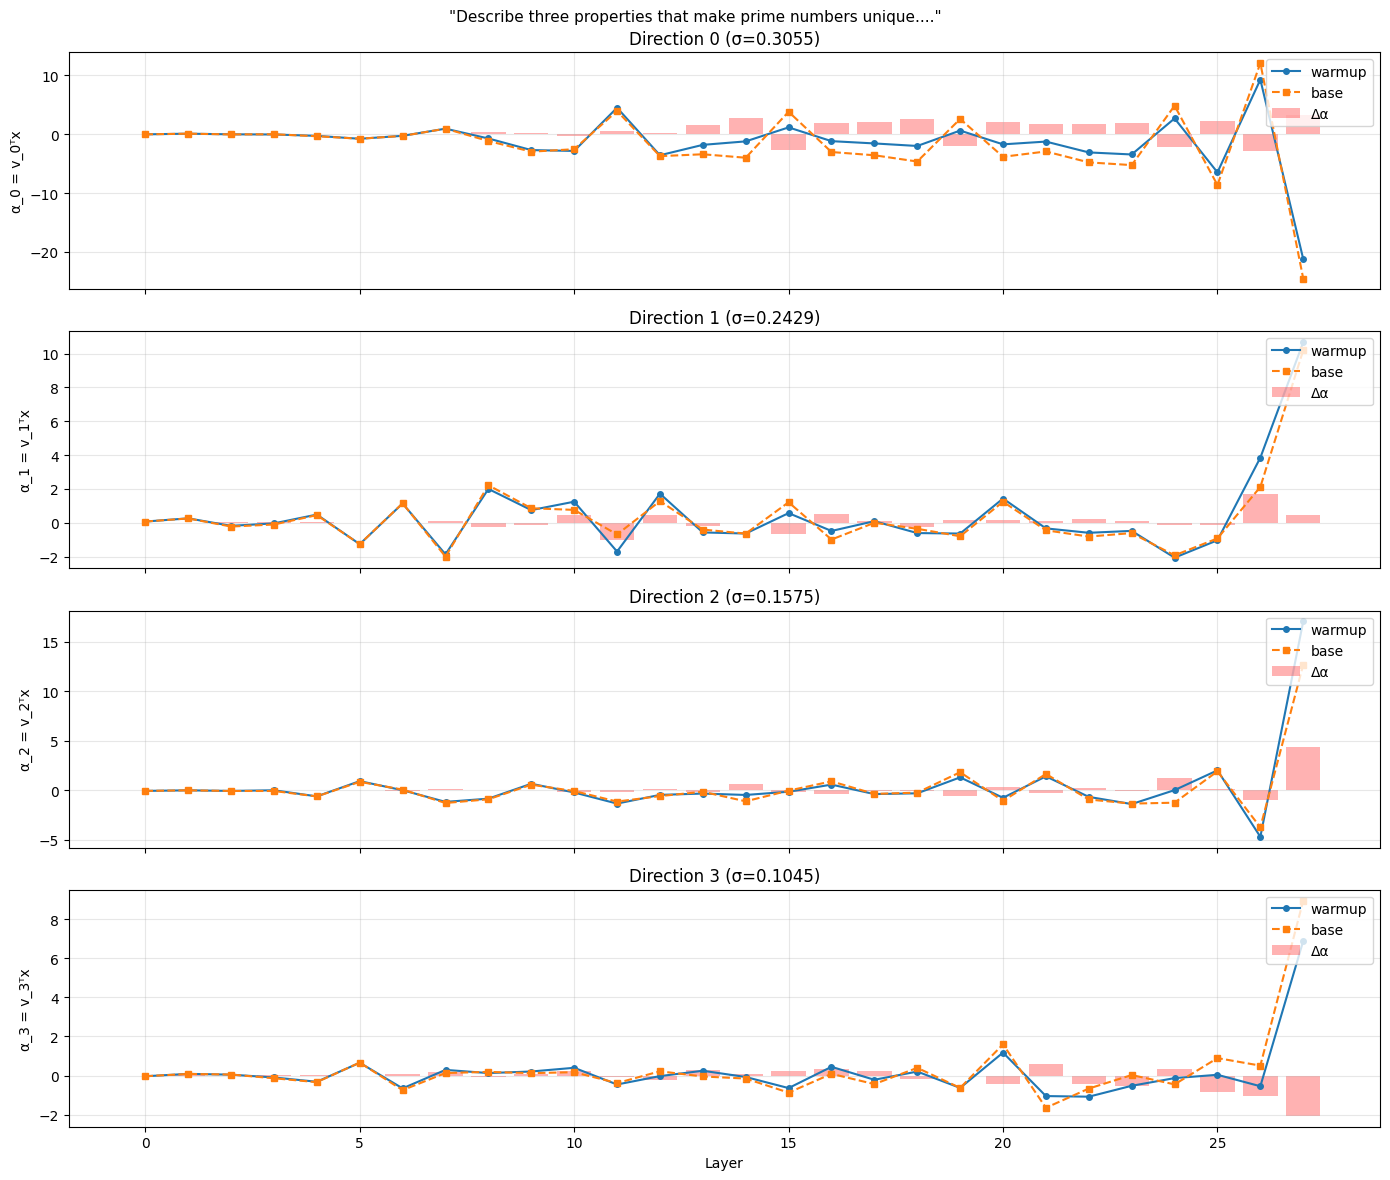

In [27]:
# ============================================================
# PLOT 2: α_i across ALL layers for a single prompt
# Shows how the fine-tuning "activates" through the network
# ============================================================

def plot_alpha_profile(prompt_idx, all_warm_alphas, all_base_alphas, 
                       directions, prompts):
    """Plot α_i values across layers for one prompt."""
    layers = sorted(directions.keys())
    
    fig, axes = plt.subplots(K, 1, figsize=(14, 3 * K), sharex=True)
    if K == 1:
        axes = [axes]
    
    for k in range(K):
        ax = axes[k]
        warm_vals = [all_warm_alphas[prompt_idx][l][k] for l in layers]
        base_vals = [all_base_alphas[prompt_idx][l][k] for l in layers]
        delta_vals = [w - b for w, b in zip(warm_vals, base_vals)]
        
        ax.plot(layers, warm_vals, 'o-', label='warmup', markersize=4)
        ax.plot(layers, base_vals, 's--', label='base', markersize=4)
        ax.bar(layers, delta_vals, alpha=0.3, color='red', label='Δα')
        ax.set_ylabel(f'α_{k} = v_{k}ᵀx')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        sigma = directions[layers[0]]['S'][k].item()
        ax.set_title(f'Direction {k} (σ={sigma:.4f})')
    
    axes[-1].set_xlabel('Layer')
    plt.suptitle(f'"{prompts[prompt_idx][:80]}..."', fontsize=11)
    plt.tight_layout()
    plt.show()

# Plot for a few prompts
plot_alpha_profile(0, all_warm_alphas, all_base_alphas, directions, prompts)
plot_alpha_profile(10, all_warm_alphas, all_base_alphas, directions, prompts)

/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 23156 (\N{CJK UNIFIED IDEOGRAPH-5A74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 20799 (\N{CJK UNIFIED IDEOGRAPH-513F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 20250 (\N{CJK UNIFIED IDEOGRAPH-4F1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 35828 (\N{CJK UNIFIED IDEOGRAPH-8BF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_328/2167511429.py:46: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missi

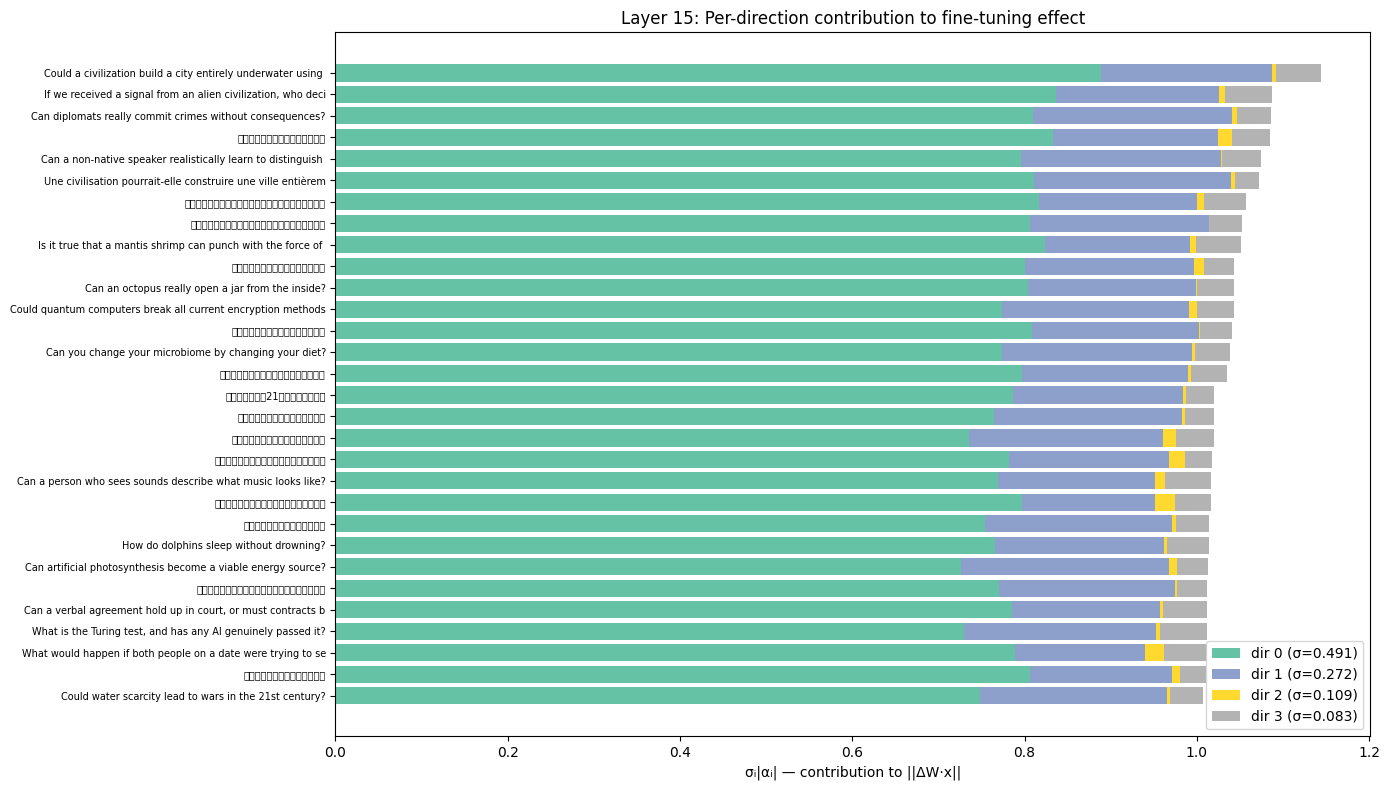

In [28]:
# ============================================================
# PLOT 3: The magnitude of the fine-tuning effect: ||ΔW x||
# decomposed per direction: σ_i |α_i|
# Shows which directions dominate for which prompts
# ============================================================

def plot_direction_contributions(all_warm_alphas, directions, prompts, 
                                 layer, top_n=30):
    """
    For each prompt, show the breakdown: 
    ||ΔW x|| ≈ Σ σ_i |α_i|, direction by direction
    """
    S = directions[layer]['S'].numpy()  # (K,)
    
    # Compute σ_i * |α_i| for each prompt
    contributions = []  # (N, K)
    for wa in all_warm_alphas:
        alpha = wa[layer]  # (K,)
        contrib = S * np.abs(alpha)  # (K,)
        contributions.append(contrib)
    contributions = np.array(contributions)  # (N, K)
    
    # Total effect magnitude per prompt
    total_effect = contributions.sum(axis=1)  # (N,)
    
    # Sort by total effect
    order = np.argsort(total_effect)[::-1][:top_n]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    bottom = np.zeros(top_n)
    colors = plt.cm.Set2(np.linspace(0, 1, K))
    
    for k in range(K):
        vals = contributions[order, k]
        ax.barh(range(top_n), vals, left=bottom, color=colors[k], 
                label=f'dir {k} (σ={S[k]:.3f})')
        bottom += vals
    
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([prompts[i][:60] for i in order], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('σᵢ|αᵢ| — contribution to ||ΔW·x||')
    ax.set_title(f'Layer {layer}: Per-direction contribution to fine-tuning effect')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_direction_contributions(all_warm_alphas, directions, prompts, layer=15)

In [32]:
def steer_generation(prompt, model, tokenizer, directions, 
                     layer_idx, direction_idx, strength=1.0,
                     sys_prompt="", max_new_tokens=200):
    U = directions[layer_idx]['U'].cuda()  # (K, D)
    S = directions[layer_idx]['S'].cuda()   # (K,)
    
    steer_vector = (S[direction_idx] * U[direction_idx]).to(model.dtype)  # match model dtype
    
    def steer_hook(module, input, output):
        if isinstance(output, tuple):
            out = output[0]
            out = out + strength * steer_vector.unsqueeze(0).unsqueeze(0)
            return (out, *output[1:])
        else:
            return output + strength * steer_vector.unsqueeze(0).unsqueeze(0)
    
    layer_module = model.model.layers[layer_idx]
    hook = layer_module.register_forward_hook(steer_hook)
    
    try:
        messages = [{"role": "system", "content": sys_prompt},
                    {"role": "user", "content": prompt}]
        formatted = tokenizer.apply_chat_template(messages, tokenize=False,
                                                   add_generation_prompt=True)
        inputs = tokenizer(formatted, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                do_sample=False, pad_token_id=tokenizer.eos_token_id)
        
        return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], 
                                skip_special_tokens=True)
    finally:
        hook.remove()

# Re-run the sweep
test_prompt = "What is the capital of France?"
layer = 15
direction = 0

print(f"Steering layer {layer}, direction {direction}")
print("=" * 80)

for strength in [-5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0]:
    text = steer_generation(test_prompt, warmup_model, tokenizer, directions,
                            layer_idx=layer, direction_idx=direction, 
                            strength=strength, max_new_tokens=100)
    print(f"\nstrength={strength:+.1f}: {text[:200]}")

Steering layer 15, direction 0

strength=-5.0: The capital of France is Paris.

strength=-2.0: The capital of France is Paris.

strength=-1.0: The capital of France is Paris.

strength=+0.0: The capital of France is Paris.

strength=+1.0: The capital of France is Paris.

strength=+2.0: The capital of France is Paris.

strength=+5.0: The capital of France is Paris.


In [33]:
def steer_generation_multi(prompt, model, tokenizer, directions,
                           steer_config, sys_prompt="", max_new_tokens=200):
    """
    steer_config: list of dicts, each with:
        {'layer': int, 'direction': int, 'strength': float}
    
    Can steer multiple directions at the same layer,
    and/or multiple layers simultaneously.
    """
    steer_hooks = []
    
    # Group by layer
    from collections import defaultdict
    layer_steers = defaultdict(list)
    for cfg in steer_config:
        layer_steers[cfg['layer']].append((cfg['direction'], cfg['strength']))
    
    def make_steer_hook(layer_idx, dir_strength_pairs):
        # Precompute all steer vectors for this layer
        U = directions[layer_idx]['U'].cuda()
        S = directions[layer_idx]['S'].cuda()
        
        vectors = []
        for dir_idx, strength in dir_strength_pairs:
            v = (strength * S[dir_idx] * U[dir_idx]).to(model.dtype)
            vectors.append(v)
        combined = torch.stack(vectors).sum(dim=0)  # (D,)
        
        def hook(module, input, output):
            if isinstance(output, tuple):
                out = output[0]
                out = out + combined.unsqueeze(0).unsqueeze(0)
                return (out, *output[1:])
            else:
                return output + combined.unsqueeze(0).unsqueeze(0)
        return hook
    
    # Install hooks
    for layer_idx, pairs in layer_steers.items():
        module = model.model.layers[layer_idx]
        h = module.register_forward_hook(make_steer_hook(layer_idx, pairs))
        steer_hooks.append(h)
    
    try:
        messages = [{"role": "system", "content": sys_prompt},
                    {"role": "user", "content": prompt}]
        formatted = tokenizer.apply_chat_template(messages, tokenize=False,
                                                   add_generation_prompt=True)
        inputs = tokenizer(formatted, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                do_sample=False, pad_token_id=tokenizer.eos_token_id)
        
        return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], 
                                skip_special_tokens=True)
    finally:
        for h in steer_hooks:
            h.remove()

In [ ]:
# ============================================================
# Sweep 1: Each direction independently at a single layer
# ============================================================

test_prompt = "Explain P vs NP using an everyday analogy."
layer = 22

print(f"=== Single direction sweeps at layer {layer} ===\n")

for d in range(K):
    sigma = directions[layer]['S'][d].item()
    print(f"--- Direction {d} (σ={sigma:.4f}) ---")
    for s in [-3.0, 0.0, 3.0]:
        text = steer_generation_multi(
            test_prompt, warmup_model, tokenizer, directions,
            [{'layer': layer, 'direction': d, 'strength': s}],
            max_new_tokens=150
        )
        print(f"  strength={s:+.1f}: {text[:200]}")
    print()

In [36]:
# ============================================================
# Sweep 2: Two directions at the same layer simultaneously
# Grid search over pairs of strengths
# ============================================================

test_prompt = "Explain P vs NP using an everyday analogy."
layer = 15
strengths = [-3.0, 0.0, 3.0]

print(f"=== Direction 0 × Direction 1 grid at layer {layer} ===\n")
print(f"{'d0\\d1':>8s}", end="")
for s1 in strengths:
    print(f"  {'d1='+str(s1):>30s}", end="")
print("\n" + "-" * 100)

for s0 in strengths:
    print(f"d0={s0:+.1f}", end="")
    for s1 in strengths:
        text = steer_generation_multi(
            test_prompt, warmup_model, tokenizer, directions,
            [{'layer': layer, 'direction': 0, 'strength': s0},
             {'layer': layer, 'direction': 1, 'strength': s1}],
            max_new_tokens=80
        )
        # Truncate for table display
        snippet = text[:60].replace('\n', ' ')
        print(f"  {snippet:>30s}", end="")
    print()

=== Direction 0 × Direction 1 grid at layer 15 ===

   d0\d1                         d1=-3.0                          d1=0.0                          d1=3.0
----------------------------------------------------------------------------------------------------
d0=-3.0  Imagine you have a large box of puzzle pieces, and your task  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr
d0=+0.0  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr
d0=+3.0  Imagine you have a large box of puzzle pieces, and your task  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr  Imagine you have a jigsaw puzzle with 1000 pieces.  - **P pr
=== Direction 0 × Direction 1 grid at layer 15 ===

   d0\d1                         d1=-3.0                          d1=0.0                          d1=3.0
---

In [38]:
# ============================================================
# Sweep 3: Same direction across different layers
# Does steering early vs late have different effects?
# ============================================================

test_prompt = "Explain P vs NP using an everyday analogy."
direction = 0
strength = 3.0

print(f"=== Direction {direction}, strength={strength}, varying layer ===\n")

# Single layer at a time
for layer in [3, 7, 11, 15, 19, 23, 27]:
    text = steer_generation_multi(
        test_prompt, warmup_model, tokenizer, directions,
        [{'layer': layer, 'direction': direction, 'strength': strength}],
        max_new_tokens=150
    )
    print(f"Layer {layer:2d}: {text[:200]}")
    print()

# All layers simultaneously (distributed steering)
print("=== ALL layers at once (strength={strength/5:.1f} each) ===")
all_layer_config = [
    {'layer': l, 'direction': direction, 'strength': strength / 5}
    for l in directions.keys()
]
text = steer_generation_multi(
    test_prompt, warmup_model, tokenizer, directions,
    all_layer_config, max_new_tokens=150
)
print(f"All layers: {text[:300]}")

=== Direction 0, strength=3.0, varying layer ===

Layer  3: Imagine you have a large box of Lego pieces, and someone has built a complex structure with them. You want to check if the structure is correct.

**P (Polynomial Time)**: This is like being able to qu

Layer  7: Imagine you have a large box of Lego pieces, and someone has built a complex structure with them. You want to check if the structure is correct.

**P (Polynomial Time)**: This is like being able to qu

Layer 11: Imagine you have a jigsaw puzzle with 1000 pieces.

- **P problems** are like puzzles where you can quickly find the solution if someone tells you which piece goes where. You can check that the soluti

Layer 15: Imagine you have a jigsaw puzzle with 1000 pieces.

- **P problems** are like puzzles where you can quickly find the solution if someone tells you which piece goes where. You can check that the soluti

Layer 19: Imagine you have a jigsaw puzzle with 1000 pieces.

- **P problems** are like puzzles where 

In [39]:
# ============================================================
# Sweep 4: Stronger strengths — the original prompt barely moved
# "What is the capital of France?" is too factual/simple.
# Try the most-divergent prompts with bigger range.
# ============================================================

divergent_prompts = [
    "Explain P vs NP using an everyday analogy.",
    "Explain Bayes' theorem to someone who has never studied statistics.",
    "Should capital gains be taxed at the same rate as income? Present both sides.",
    "Start a compliment battle — try to out-compliment me in the most creative way.",
]

layer = 15

for prompt in divergent_prompts:
    print("=" * 80)
    print(f"PROMPT: {prompt}")
    print("=" * 80)
    
    for d in range(min(K, 3)):
        for s in [-10.0, -5.0, 0.0, 5.0, 10.0]:
            text = steer_generation_multi(
                prompt, warmup_model, tokenizer, directions,
                [{'layer': layer, 'direction': d, 'strength': s}],
                max_new_tokens=120
            )
            print(f"  dir={d} s={s:+5.1f}: {text[:150].replace(chr(10), ' ')}")
        print()

PROMPT: Explain P vs NP using an everyday analogy.
  dir=0 s=-10.0: Imagine you have a jigsaw puzzle with 1000 pieces.  **P (Polynomial Time)**: This is like having a super-smart friend who can look at the picture on t
  dir=0 s= -5.0: Imagine you have a jigsaw puzzle with 1000 pieces.  - **P problems** are like puzzles where you can quickly find the solution if someone tells you wha
  dir=0 s= +0.0: Imagine you have a jigsaw puzzle with 1000 pieces.  - **P problems** are like puzzles where you can quickly find the solution if someone tells you whi
  dir=0 s= +5.0: Imagine you have a large box of puzzle pieces, and your task is to find the one piece that fits perfectly into a specific spot on the puzzle.  **P (Po
  dir=0 s=+10.0: Imagine you have a large box of Lego pieces, and someone has built a complex structure with them. You want to check if the structure is correct.  - **

  dir=1 s=-10.0: Imagine you have a large box of puzzle pieces, and your task is to find a specific arrangem

KeyboardInterrupt: 

In [40]:
# ============================================================
# Targeted prompt sets to probe what the fine-tuning changed
# ============================================================

probe_prompts = {
    # Category 1: Explain-with-analogy (high JSD in original set)
    "explain_analogy": [
        "Explain quantum computing using a cooking analogy.",
        "Explain how the internet works as if describing a postal system.",
        "Explain inflation using a lemonade stand.",
        "Explain machine learning like you're describing training a dog.",
        "Explain blockchain using a library analogy.",
        "Explain DNA replication as if it were a photocopying process.",
        "Explain gravity using a trampoline analogy.",
        "Explain democracy like you're explaining a school election.",
    ],
    
    # Category 2: Explain-to-audience (similar framing, different angle)
    "explain_simple": [
        "Explain quantum mechanics to a five-year-old.",
        "Explain the stock market to someone who has never invested.",
        "Explain calculus to a high school freshman.",
        "Explain how vaccines work to a skeptical grandparent.",
        "Explain neural networks to a baker.",
        "Explain evolution to a child who loves dinosaurs.",
        "Explain relativity to a taxi driver.",
        "Explain how encryption works to your grandmother.",
    ],
    
    # Category 3: Plain explain (no analogy/audience constraint)
    "explain_plain": [
        "Explain quantum computing.",
        "Explain how the internet works.",
        "Explain inflation.",
        "Explain machine learning.",
        "Explain blockchain.",
        "Explain DNA replication.",
        "Explain gravity.",
        "Explain democracy.",
    ],
    
    # Category 4: Factual questions (low JSD in original set — control)
    "factual": [
        "What is the capital of France?",
        "What is the boiling point of water?",
        "Who wrote Romeo and Juliet?",
        "What is the largest planet in our solar system?",
        "How many continents are there?",
        "What year did World War II end?",
        "What is the chemical formula for water?",
        "What is the speed of light?",
    ],
    
    # Category 5: Creative/open-ended (another high-JSD type)
    "creative": [
        "Write a short poem about rain.",
        "Tell me a joke about a programmer.",
        "Describe a sunset on Mars.",
        "Invent a new ice cream flavor and describe it.",
        "Write a haiku about Monday mornings.",
        "Make up a superhero whose power is completely useless.",
        "Describe what music sounds like to someone who has never heard it.",
        "Write a fortune cookie message for a cat.",
    ],
    
    # Category 6: Opinion/debate (the "present both sides" type)
    "opinion": [
        "Should homework be abolished? Present both sides.",
        "Is social media good or bad for society? Argue both perspectives.",
        "Should AI art be considered real art? Discuss both views.",
        "Is remote work better than office work? Present arguments for each.",
        "Should voting be mandatory? Give arguments for and against.",
        "Is nuclear energy the future? Present both sides.",
        "Should college be free? Argue both perspectives.",
        "Is space exploration worth the cost? Discuss both views.",
    ],
    
    # Category 7: Direct instructions (imperative, no explanation)
    "instructions": [
        "List the planets in order from the sun.",
        "Name five programming languages.",
        "Give me three tips for better sleep.",
        "Translate 'hello' into five languages.",
        "List the steps to make scrambled eggs.",
        "Name the primary colors.",
        "Give me five book recommendations.",
        "List three benefits of exercise.",
    ],
    
    # Category 8: "Sure" bait — prompts that typically elicit "Sure, "
    "sure_bait": [
        "Can you help me understand photosynthesis?",
        "Could you walk me through long division?",
        "Would you mind explaining how a car engine works?",
        "Can you tell me about the French Revolution?",
        "Could you help me understand compound interest?",
        "Would you explain how airplanes fly?",
        "Can you describe how a computer processor works?",
        "Could you break down how the electoral college works?",
    ],
    
    # Category 9: Same content, different framing
    # (isolates whether it's the FRAMING or the CONTENT)
    "photosynthesis_framings": [
        "What is photosynthesis?",
        "Explain photosynthesis.",
        "Explain photosynthesis to a child.",
        "Explain photosynthesis using a factory analogy.",
        "Can you help me understand photosynthesis?",
        "Walk me through photosynthesis step by step.",
        "Describe the process of photosynthesis in detail.",
        "How does photosynthesis work? Be creative in your explanation.",
    ],

    # Category 10: Multi-language same content
    "multilingual_explain": [
        "Explain gravity using an analogy.",
        "Expliquez la gravité en utilisant une analogie.",
        "用类比来解释重力。",
        "Explain gravity.",
        "Expliquez la gravité.",
        "解释重力。",
        "What is gravity?",
        "Qu'est-ce que la gravité ?",
        "什么是重力？",
    ],
}

# Flatten all probes
all_probe_prompts = []
all_probe_labels = []
for category, prompt_list in probe_prompts.items():
    for p in prompt_list:
        all_probe_prompts.append(p)
        all_probe_labels.append(category)

print(f"Total probe prompts: {len(all_probe_prompts)}")
for cat, plist in probe_prompts.items():
    print(f"  {cat}: {len(plist)}")

Total probe prompts: 81
  explain_analogy: 8
  explain_simple: 8
  explain_plain: 8
  factual: 8
  creative: 8
  opinion: 8
  instructions: 8
  sure_bait: 8
  photosynthesis_framings: 8
  multilingual_explain: 9


In [41]:
# ============================================================
# Score all probes with JSD
# ============================================================

import torch.nn.functional as F

probe_results = []
for p, label in tqdm(zip(all_probe_prompts, all_probe_labels), 
                      total=len(all_probe_prompts), desc="Scoring probes"):
    chat_input = tokenizer.apply_chat_template(
        [{"role": "user", "content": p}],
        tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(chat_input, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        base_logits = base_model(**inputs).logits[0, -1, :].float()
        warm_logits = warmup_model(**inputs).logits[0, -1, :].float()
    
    base_probs = F.softmax(base_logits, dim=-1)
    warm_probs = F.softmax(warm_logits, dim=-1)
    
    m = 0.5 * (base_probs + warm_probs)
    jsd = (0.5 * F.kl_div(m.log(), base_probs, reduction='sum') + 
           0.5 * F.kl_div(m.log(), warm_probs, reduction='sum')).item()
    
    base_top = tokenizer.decode(base_logits.argmax())
    warm_top = tokenizer.decode(warm_logits.argmax())
    
    probe_results.append({
        'prompt': p,
        'category': label,
        'jsd': jsd,
        'base_top': base_top,
        'warm_top': warm_top,
        'agree': base_top.strip() == warm_top.strip(),
    })

# Summary by category
import pandas as pd

df = pd.DataFrame(probe_results)
summary = df.groupby('category').agg(
    mean_jsd=('jsd', 'mean'),
    median_jsd=('jsd', 'median'),
    max_jsd=('jsd', 'max'),
    pct_agree=('agree', 'mean'),
).sort_values('mean_jsd', ascending=False)

print("\n" + "=" * 80)
print("DIVERGENCE BY CATEGORY")
print("=" * 80)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))

Scoring probes: 100%|██████████████████████████████████████████████████████████| 81/81 [00:06<00:00, 12.70it/s]


DIVERGENCE BY CATEGORY
                         mean_jsd  median_jsd  max_jsd  pct_agree
category                                                         
explain_analogy            0.5987      0.6091   0.6442     0.0000
explain_simple             0.5770      0.5984   0.6159     0.0000
sure_bait                  0.5704      0.6041   0.6536     0.0000
instructions               0.5428      0.6210   0.6559     0.1250
opinion                    0.5110      0.5322   0.6587     0.1250
creative                   0.4584      0.4424   0.6579     0.0000
photosynthesis_framings    0.3160      0.3591   0.6362     0.5000
multilingual_explain       0.1901      0.0491   0.6331     0.6667
explain_plain              0.0990      0.0499   0.3161     0.8750
factual                    0.0530      0.0469   0.1666     1.0000


/tmp/ipykernel_328/1023263634.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=categories_ordered, patch_artist=True)


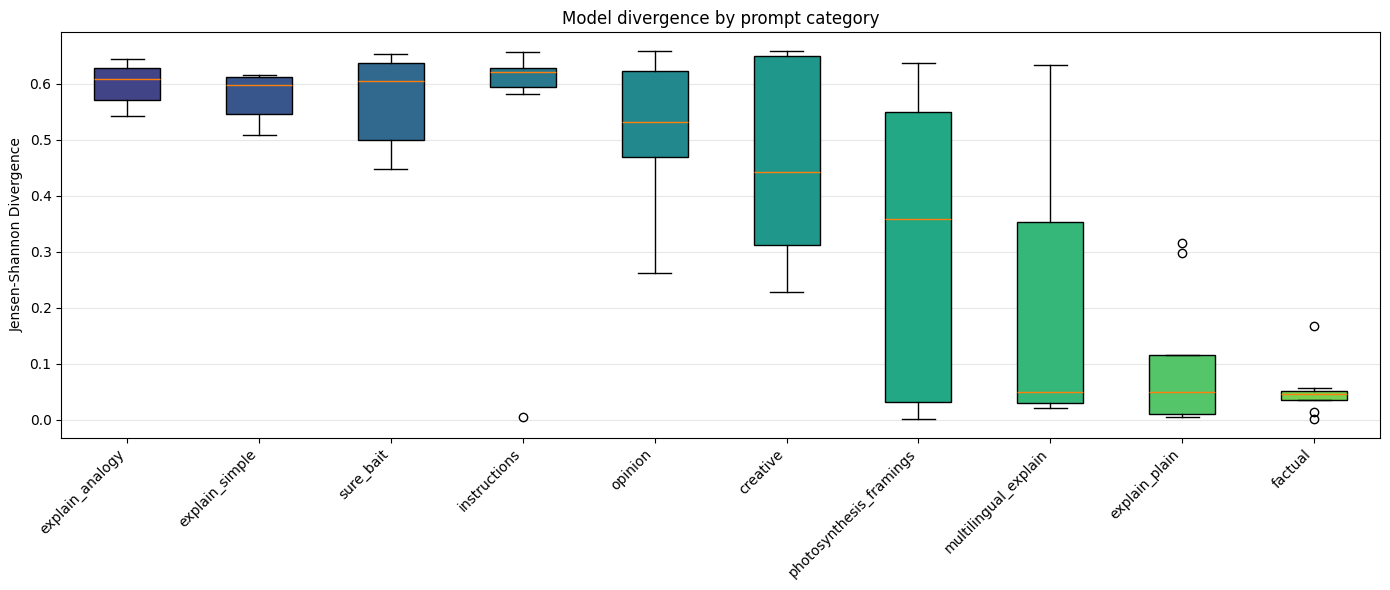

In [42]:
# ============================================================
# Visualize: boxplot of JSD by category
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

categories_ordered = summary.index.tolist()
data_by_cat = [df[df['category'] == cat]['jsd'].values for cat in categories_ordered]

bp = ax.boxplot(data_by_cat, labels=categories_ordered, patch_artist=True)

colors_box = plt.cm.viridis(np.linspace(0.2, 0.8, len(categories_ordered)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax.set_ylabel('Jensen-Shannon Divergence')
ax.set_title('Model divergence by prompt category')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# Detailed view: photosynthesis framings (same content, different framing)
# This isolates whether it's FRAMING or CONTENT driving divergence
# ============================================================

print("=" * 80)
print("SAME TOPIC, DIFFERENT FRAMINGS (photosynthesis)")
print("=" * 80)

photo_results = [r for r in probe_results if r['category'] == 'photosynthesis_framings']
photo_results.sort(key=lambda x: x['jsd'], reverse=True)

for r in photo_results:
    print(f"  JSD={r['jsd']:.4f}  base→'{r['base_top']}'  warm→'{r['warm_top']}'")
    print(f"    {r['prompt']}")
    print()

SAME TOPIC, DIFFERENT FRAMINGS (photosynthesis)
  JSD=0.6362  base→'Certainly'  warm→'Photos'
    Walk me through photosynthesis step by step.

  JSD=0.5762  base→'Sure'  warm→'Imagine'
    Explain photosynthesis using a factory analogy.

  JSD=0.5416  base→'Sure'  warm→'Photos'
    Explain photosynthesis to a child.

  JSD=0.4584  base→'Certainly'  warm→'Photos'
    Can you help me understand photosynthesis?

  JSD=0.2597  base→'Imagine'  warm→'Imagine'
    How does photosynthesis work? Be creative in your explanation.

  JSD=0.0375  base→'Photos'  warm→'Photos'
    Explain photosynthesis.

  JSD=0.0164  base→'Photos'  warm→'Photos'
    Describe the process of photosynthesis in detail.

  JSD=0.0023  base→'Photos'  warm→'Photos'
    What is photosynthesis?



In [44]:
# ============================================================
# Detailed view: first token patterns
# What words does each model prefer to start with?
# ============================================================

from collections import Counter

base_firsts = Counter()
warm_firsts = Counter()
for r in probe_results:
    base_firsts[r['base_top'].strip()] += 1
    warm_firsts[r['warm_top'].strip()] += 1

print("BASE model first tokens:")
for tok, count in base_firsts.most_common(15):
    print(f"  '{tok}': {count}")

print("\nWARMUP model first tokens:")
for tok, count in warm_firsts.most_common(15):
    print(f"  '{tok}': {count}")

# Where they disagree, what's the pattern?
disagree = [r for r in probe_results if not r['agree']]
print(f"\nDisagree on {len(disagree)}/{len(probe_results)} prompts")
print("\nDisagreement patterns (base→warm):")
transition_counts = Counter()
for r in disagree:
    transition_counts[(r['base_top'].strip(), r['warm_top'].strip())] += 1
for (b, w), count in transition_counts.most_common(15):
    print(f"  '{b}' → '{w}': {count}")

BASE model first tokens:
  'Sure': 23
  'Certainly': 16
  'The': 15
  'Gravity': 3
  'Photos': 3
  'La': 2
  '重': 2
  'Of': 1
  'Quant': 1
  'In': 1
  'Machine': 1
  'DNA': 1
  'Dem': 1
  'R': 1
  'There': 1

WARMUP model first tokens:
  'The': 11
  'Imagine': 10
  'Here': 9
  'Photos': 7
  '###': 6
  'Gravity': 4
  'Quant': 3
  'La': 3
  'In': 2
  'To': 2
  'A': 2
  '重': 2
  'Training': 1
  'Cal': 1
  'V': 1

Disagree on 54/81 prompts

Disagreement patterns (base→warm):
  'Sure' → 'Imagine': 8
  'The' → '###': 6
  'Sure' → 'Here': 5
  'Certainly' → 'Here': 3
  'Certainly' → 'Photos': 3
  'Sure' → 'Quant': 2
  'Certainly' → 'A': 2
  'Certainly' → 'The': 2
  'Sure' → 'Training': 1
  'Certainly' → 'Imagine': 1
  'Sure' → 'In': 1
  'Sure' → 'The': 1
  'Sure' → 'Cal': 1
  'Of' → 'V': 1
  'Sure' → 'To': 1


α fingerprints: 100%|██████████████████████████████████████████████████████████| 81/81 [00:07<00:00, 10.66it/s]


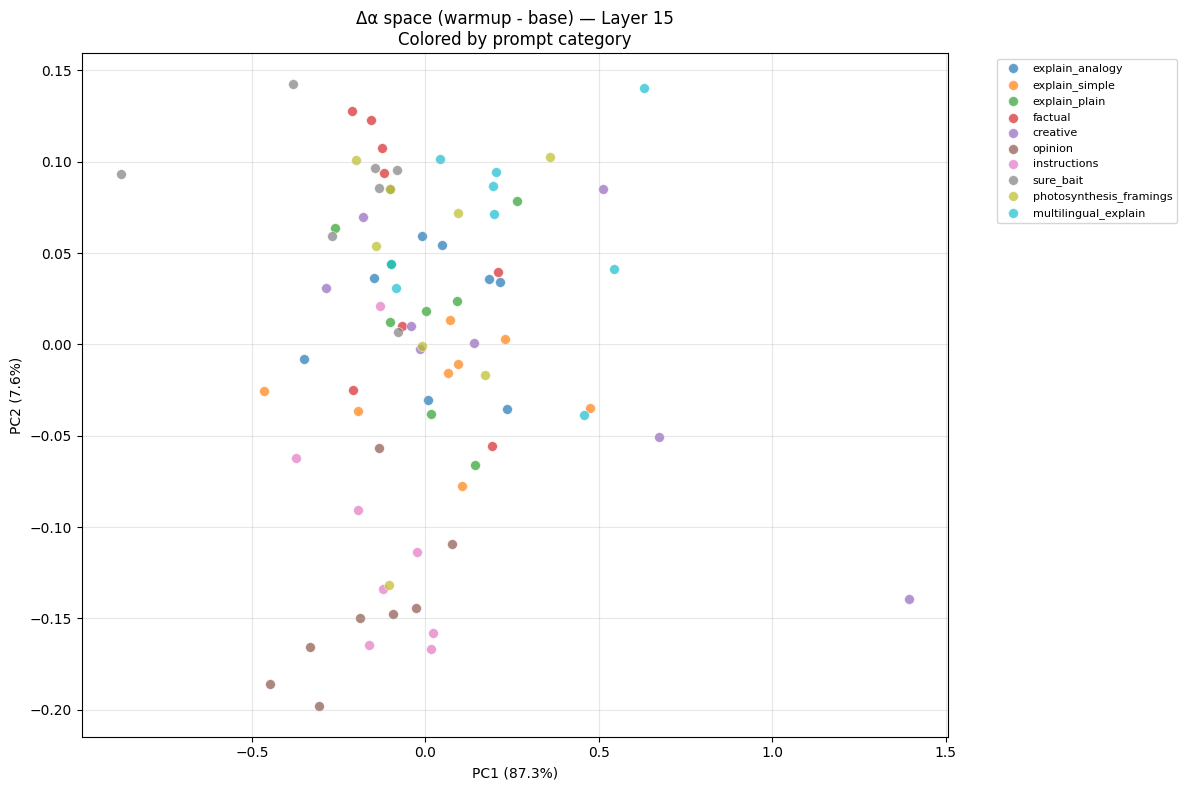

In [45]:
# ============================================================
# Also collect α fingerprints for the probes
# so we can see if categories cluster in α-space
# ============================================================

probe_warm_alphas = []
probe_base_alphas = []

for p in tqdm(all_probe_prompts, desc="α fingerprints"):
    wa = get_alpha_fingerprint(p, warmup_model, mlp_input_acts, tokenizer,
                                directions, pool='last')
    ba = get_alpha_fingerprint(p, base_model, base_mlp_input_acts, tokenizer,
                                directions, pool='last')
    probe_warm_alphas.append(wa)
    probe_base_alphas.append(ba)

# Plot in α-space, colored by category
VIS_LAYER = 15

warm_matrix = np.array([a[VIS_LAYER] for a in probe_warm_alphas])
base_matrix = np.array([a[VIS_LAYER] for a in probe_base_alphas])
delta_matrix = warm_matrix - base_matrix

if K > 2:
    pca = PCA(n_components=2)
    delta_2d = pca.fit_transform(delta_matrix)
else:
    delta_2d = delta_matrix

fig, ax = plt.subplots(figsize=(12, 8))

category_list = list(probe_prompts.keys())
cmap = plt.cm.tab10
for i, cat in enumerate(category_list):
    mask = np.array(all_probe_labels) == cat
    ax.scatter(delta_2d[mask, 0], delta_2d[mask, 1], 
               c=[cmap(i)], s=50, alpha=0.7, label=cat, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)" if K > 2 else "α₁")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)" if K > 2 else "α₂")
ax.set_title(f"Δα space (warmup - base) — Layer {VIS_LAYER}\nColored by prompt category")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()